In [227]:
import os

# 填入你圖片上拿到的完整 API Token
os.environ['KAGGLE_API_TOKEN'] = "KGAT_ee0cb89df4a8c4eb288c28c19fcbdebf"

# 重新下載資料集
!kaggle competitions download -c house-prices-advanced-regression-techniques

# 解壓縮
!unzip -o house-prices-advanced-regression-techniques.zip

house-prices-advanced-regression-techniques.zip: Skipping, found more recently modified local copy (use --force to force download)


'unzip' ���O�����Υ~���R�O�B�i���檺�{���Χ妸�ɡC


Dataprocessing

In [228]:
import pandas as pd

# 1. 先讀取剛剛解壓縮出來的訓練資料，建立 train_data 變數
train_data = pd.read_csv('train.csv')

# 2. 確認讀取成功後，再執行觀察資料的指令
print("資料維度:", train_data.shape)
print("-" * 30)

# 查看各欄位的資料型態與非空值數量
train_data.info()

資料維度: (1460, 81)
------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    

In [275]:
posn_houses = train_data[train_data['Condition2'] == 'PosN']

# 為了方便觀察，我們只印出 ID 以及幾個決定房價的關鍵欄位
cols_to_look = ['Id', 'SalePrice', 'Neighborhood', 'OverallQual', 'GrLivArea', 'Condition1', 'Condition2']
print(posn_houses[cols_to_look])

      Id  SalePrice Neighborhood  OverallQual  GrLivArea Condition1 Condition2
523  524     184750      Edwards           10       4676       PosN       PosN
825  826     385000      NridgHt           10       2084       PosN       PosN


In [229]:
# 1. 檢視缺失值的比例
missing_ratio = train_data.isnull().sum() / len(train_data)
missing_features = missing_ratio[missing_ratio > 0].sort_values(ascending=False)
print("各欄位缺失比例：\n", missing_features.head(10))
print("-" * 30)

各欄位缺失比例：
 PoolQC          0.995205
MiscFeature     0.963014
Alley           0.937671
Fence           0.807534
MasVnrType      0.597260
FireplaceQu     0.472603
LotFrontage     0.177397
GarageType      0.055479
GarageYrBlt     0.055479
GarageFinish    0.055479
dtype: float64
------------------------------


In [230]:
# 階段一：特徵工程 (Feature Engineering)
# 把有意義的缺失值轉化為二元特徵 (1:有, 0:無)
# ==========================================
train_data['HasPool'] = train_data['PoolQC'].notnull().astype(int)
train_data['HasAlley'] = train_data['Alley'].notnull().astype(int)
train_data['HasFence'] = train_data['Fence'].notnull().astype(int)
train_data['HasMisc'] = train_data['MiscFeature'].notnull().astype(int)

In [231]:
train_data_cleaned = train_data.drop(columns=['PoolQC', 'Alley', 'Fence', 'MiscFeature'])

In [232]:
# 取得所有數值型特徵的統計摘要
summary_stats = train_data_cleaned.describe()

# 顯示結果
summary_stats

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice,HasPool,HasAlley,HasFence,HasMisc
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890,0.004795,0.062329,0.192466,0.036986
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883,0.069100,0.241835,0.394372,0.188793
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000,0.000000,0.000000,0.000000,0.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000,0.000000,0.000000,0.000000,0.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000,0.000000,0.000000,0.000000,0.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000,0.000000,0.000000,0.000000,0.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000,1.000000,1.000000,1.000000,1.000000


In [233]:
# 找出剩下的所有數值型欄位
numeric_cols = train_data_cleaned.select_dtypes(include=['int64', 'float64']).columns

# 計算所有數值欄位的偏度 (Skewness) (衡量數據分佈的不對稱性，反映分佈尾部的延伸方向與程度)
skewness = train_data_cleaned[numeric_cols].skew()

for col in numeric_cols:
    if train_data_cleaned[col].isnull().sum() > 0:

        # 取得該欄位的偏度絕對值
        col_skew = abs(skewness[col])

        # 判斷邏輯：如果偏度大於 1 (高度偏斜)，用中位數；否則用平均值
        if col_skew > 1.0:
            fill_val = train_data_cleaned[col].median()
            method = "中位數 (Median)"
        else:
            fill_val = train_data_cleaned[col].mean()
            method = "平均值 (Mean)"

        # 執行填補
        train_data_cleaned[col] = train_data_cleaned[col].fillna(fill_val)
        print(f"欄位 {col} (偏度: {col_skew:.2f}) -> 使用 {method} 填補")

print("-" * 30)
print("數值型空缺填補完成！")
print("目前還有缺失值的欄位數量：", train_data_cleaned.isnull().sum().max())

欄位 LotFrontage (偏度: 2.16) -> 使用 中位數 (Median) 填補
欄位 MasVnrArea (偏度: 2.67) -> 使用 中位數 (Median) 填補
欄位 GarageYrBlt (偏度: 0.65) -> 使用 平均值 (Mean) 填補
------------------------------
數值型空缺填補完成！
目前還有缺失值的欄位數量： 872


In [234]:
# 找出所有文字型特徵
categorical_cols = train_data_cleaned.select_dtypes(include=['object']).columns

print("--- 潛在危險的眾數填補檢查 ---")
for col in categorical_cols:
    missing_count = train_data_cleaned[col].isnull().sum()

    # 只檢查有缺失值的欄位
    if missing_count > 0:
        missing_ratio = missing_count / len(train_data_cleaned)

        # 看看這個欄位裡，各類別佔的比例
        value_counts = train_data_cleaned[col].value_counts(normalize=True)
        top_1_ratio = value_counts.iloc[0] if len(value_counts) > 0 else 0
        top_2_ratio = value_counts.iloc[1] if len(value_counts) > 1 else 0

        print(f"\n欄位: {col}")
        print(f"缺失比例: {missing_ratio:.1%}")
        print(f"第一名(眾數)佔比: {top_1_ratio:.1%} | 第二名佔比: {top_2_ratio:.1%}")

        # 給出自動化建議
        if missing_ratio > 0.1:
            print("👉 [建議] 缺失率太高！建議填補為 'None'")
        elif (top_1_ratio - top_2_ratio) < 0.1:
            print("👉 [建議] 眾數優勢不明顯！填補眾數風險高，建議填補為 'None'")
        else:
            print("👉 [建議] 眾數具備統治力且缺失率低，可安全使用 '眾數' 填補")

--- 潛在危險的眾數填補檢查 ---

欄位: MasVnrType
缺失比例: 59.7%
第一名(眾數)佔比: 75.7% | 第二名佔比: 21.8%
👉 [建議] 缺失率太高！建議填補為 'None'

欄位: BsmtQual
缺失比例: 2.5%
第一名(眾數)佔比: 45.6% | 第二名佔比: 43.4%
👉 [建議] 眾數優勢不明顯！填補眾數風險高，建議填補為 'None'

欄位: BsmtCond
缺失比例: 2.5%
第一名(眾數)佔比: 92.1% | 第二名佔比: 4.6%
👉 [建議] 眾數具備統治力且缺失率低，可安全使用 '眾數' 填補

欄位: BsmtExposure
缺失比例: 2.6%
第一名(眾數)佔比: 67.0% | 第二名佔比: 15.5%
👉 [建議] 眾數具備統治力且缺失率低，可安全使用 '眾數' 填補

欄位: BsmtFinType1
缺失比例: 2.5%
第一名(眾數)佔比: 30.2% | 第二名佔比: 29.4%
👉 [建議] 眾數優勢不明顯！填補眾數風險高，建議填補為 'None'

欄位: BsmtFinType2
缺失比例: 2.6%
第一名(眾數)佔比: 88.3% | 第二名佔比: 3.8%
👉 [建議] 眾數具備統治力且缺失率低，可安全使用 '眾數' 填補

欄位: Electrical
缺失比例: 0.1%
第一名(眾數)佔比: 91.4% | 第二名佔比: 6.4%
👉 [建議] 眾數具備統治力且缺失率低，可安全使用 '眾數' 填補

欄位: FireplaceQu
缺失比例: 47.3%
第一名(眾數)佔比: 49.4% | 第二名佔比: 40.6%
👉 [建議] 缺失率太高！建議填補為 'None'

欄位: GarageType
缺失比例: 5.5%
第一名(眾數)佔比: 63.1% | 第二名佔比: 28.1%
👉 [建議] 眾數具備統治力且缺失率低，可安全使用 '眾數' 填補

欄位: GarageFinish
缺失比例: 5.5%
第一名(眾數)佔比: 43.9% | 第二名佔比: 30.6%
👉 [建議] 眾數具備統治力且缺失率低，可安全使用 '眾數' 填補

欄位: GarageQual
缺失比例: 5.5%
第一名(眾數)佔比: 95.1% | 第二名佔比: 3.5%


C:\Users\j1456\AppData\Local\Temp\ipykernel_19140\1539360634.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = train_data_cleaned.select_dtypes(include=['object']).columns


1. 統計學的勝利：明確該用 'None' 的欄位
   MasVnrType (缺失 59.7%) 與 FireplaceQu (缺失 47.3%)：缺失率太高。在現實中，這代表這棟房子「沒有磚石外牆」和「沒有壁爐」。填補為 'None' 是絕對正確的。

   BsmtQual 與 BsmtFinType1：雖然缺失率不高，但第一名和第二名的佔比幾乎一樣（例如 45.6% vs 43.4%）。這時候如果硬塞眾數，就是在破壞原始的分佈，工具建議填補 'None' 非常精準。

2. 完美的眾數候選人：Electrical (供電系統)
   Electrical (缺失 0.1%)：只有極少數的房子漏填，而且高達 91.4% 的房子都是使用標準的電力系統 (SBrkr)。這代表這極少數的空缺大概率只是房仲「忘記填」，直接用眾數補上是最合理的。

3. 隱藏的陷阱：「車庫」與「地下室」家族
   
   這裡有一個極度重要的實務盲點，請仔細看報告中的數字：

   GarageType, GarageFinish, GarageQual, GarageCond 的缺失率全都是一模一樣的 5.5%。

   為什麼這麼巧？因為這 5.5% 代表的是**「這棟房子根本沒有車庫」**！

   雖然診斷工具因為「第一名佔比極高 (例如 95%)」而建議你填眾數，但如果你照做了，等於是憑空幫這 5.5% 沒有車庫的房子，全部蓋了一座標準車庫！這對預測房價會造成嚴重的誤導。

   同理，Bsmt (地下室) 家族的缺失率大概都在 2.5% ~ 2.6% 左右，這代表有 2.5% 的房子沒有地下室。

In [235]:
# 1. 唯一適合用「眾數」填補的欄位
mode_cols = ['Electrical']
for col in mode_cols:
    # 找出眾數並填補
    most_freq = train_data_cleaned[col].mode()[0]
    train_data_cleaned[col] = train_data_cleaned[col].fillna(most_freq)

# 2. 其他全部填補為 'None' (代表無此設施)
# 將我們剛剛從報告中看到的欄位列出來
none_cols = [
    'MasVnrType', 'FireplaceQu',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond'
]

for col in none_cols:
    train_data_cleaned[col] = train_data_cleaned[col].fillna("None")

# 3. 最終確認
print("文字型缺失值處理完畢！")
print("目前整份資料剩餘缺失值總數：", train_data_cleaned.isnull().sum().max())

文字型缺失值處理完畢！
目前整份資料剩餘缺失值總數： 0


In [236]:
print("資料維度:", train_data_cleaned.shape)

資料維度: (1460, 81)


In [237]:
# 使用 pd.get_dummies() 自動將所有文字型特徵轉換為 One-Hot 格式
# 加上 drop_first=True (N-1 變數便可回答 N 個變數)
train_data_final = pd.get_dummies(train_data_cleaned, drop_first=True)

print("原本的資料維度:", train_data_cleaned.shape)
print("One-Hot 轉換後的資料維度:", train_data_final.shape)

# 顯示前五筆資料
train_data_final.head()

原本的資料維度: (1460, 81)
One-Hot 轉換後的資料維度: (1460, 252)


,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,1,60,65.0,8450,7,5,2003,2003,196.0,706,...,False,False,False,False,True,False,False,False,True,False
1,2,20,80.0,9600,6,8,1976,1976,0.0,978,...,False,False,False,False,True,False,False,False,True,False
2,3,60,68.0,11250,7,5,2001,2002,162.0,486,...,False,False,False,False,True,False,False,False,True,False
3,4,70,60.0,9550,7,5,1915,1970,0.0,216,...,False,False,False,False,True,False,False,False,False,False
4,5,60,84.0,14260,8,5,2000,2000,350.0,655,...,False,False,False,False,True,False,False,False,True,False


Baseline Models

In [238]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score
import numpy as np

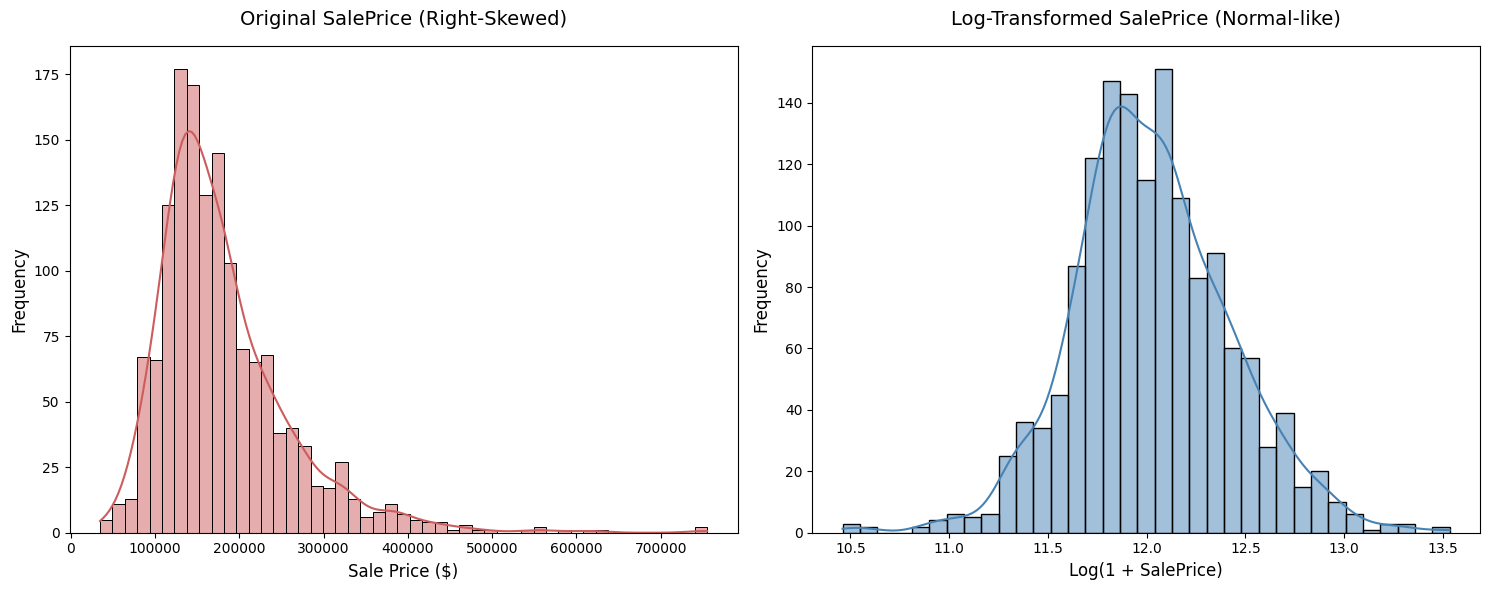

In [239]:
import matplotlib.pyplot as plt
import seaborn as sns

# 設定圖表大小 (1x2 雙拼圖)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- 左圖：原始房價 (右偏) ---
sns.histplot(train_data['SalePrice'], kde=True, ax=axes[0], color='indianred')
axes[0].set_title('Original SalePrice (Right-Skewed)', fontsize=14, pad=15)
axes[0].set_xlabel('Sale Price ($)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)

# --- 右圖：Log 轉換後的房價 (趨近常態) ---
sns.histplot(np.log1p(train_data['SalePrice']), kde=True, ax=axes[1], color='steelblue')
axes[1].set_title('Log-Transformed SalePrice (Normal-like)', fontsize=14, pad=15)
axes[1].set_xlabel('Log(1 + SalePrice)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)

plt.tight_layout()
plt.show()

 由於原始房價數據 (SalePrice) 呈現明顯的右偏分佈 (Right-skewed)，我們對其進行了對數轉換 $y = \log(1 + \text{SalePrice})$。此轉換不僅使殘差分佈更接近常態分佈以符合線性迴歸假設，同時也將絕對誤差轉化為比例誤差，使得高價屋與低價屋的預測誤差具備可比較性。

In [240]:
# 1. 萃取目標變數 y (標準做法)
y = np.log1p(train_data_final["SalePrice"])

# 2. 萃取特徵矩陣 X (踢除 SalePrice 和 Id)
X = train_data_final.drop(columns=["SalePrice", "Id"], errors="ignore")

print("特徵矩陣 X 維度:", X.shape)
print("目標變數 y 維度:", y.shape)

特徵矩陣 X 維度: (1460, 250)
目標變數 y 維度: (1460,)


In [241]:
from sklearn.model_selection import train_test_split

# 將全部資料切分為：80% 的研發集 (Dev) 與 20% 的最終期末考卷 (Final Test)
# random_state=42 確保每次切出來的結果都一樣
X_dev, X_final_test, y_dev, y_final_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [242]:
from sklearn.preprocessing import PowerTransformer
import pandas as pd

# 1. 呼叫出 PowerTransformer 的實例 (取代原本的 StandardScaler)
# method='yeo-johnson' 會自動處理左偏/右偏態
# standardize=True 會在修正偏態後，自動幫你做平均值 0、標準差 1 的標準化
scaler = PowerTransformer(method='yeo-johnson', standardize=True)

# ==========================================
# ⚠️ 第一步：對研發集 (Dev) 進行 fit_transform
# 讓模型看這 80% 的資料來「打造量尺」，並將其轉換為標準化數據
# ==========================================
X_dev_scaled = pd.DataFrame(
    scaler.fit_transform(X_dev), 
    columns=X_dev.columns, 
    index=X_dev.index
)

# ==========================================
# ⚠️ 第二步：對期末考卷 (Final Test) 進行 transform
# 絕對不可以使用 fit！只能拿 Dev 做好的量尺來轉換這 20% 的數據
# ==========================================
X_final_test_scaled = pd.DataFrame(
    scaler.transform(X_final_test), 
    columns=X_final_test.columns, 
    index=X_final_test.index
)

print("✅ 標準化完成！")
print(f"X_dev_scaled 的形狀: {X_dev_scaled.shape}")
print(f"X_final_test_scaled 的形狀: {X_final_test_scaled.shape}")

✅ 標準化完成！
X_dev_scaled 的形狀: (1168, 250)
X_final_test_scaled 的形狀: (292, 250)


進行一般標準化後，結果並沒有比原始資料的結果好
一般標準化後的結果(CV RMSE):

1. 一般線性迴歸 (Baseline): 0.1636
2. Lasso 迴歸模型 RMSE: 0.1480
3. Ridge 迴歸模型 RMSE: 0.1437

未標準化的結果(CV RMSE)：

1. 一般線性迴歸 (Baseline): 0.1657
2. Lasso 迴歸模型 RMSE: 0.1445
3. Ridge 迴歸模型 RMSE: 0.1426

利用 'yeo-johnson' 將偏態修掉可以使線性模型表現更好，然而修改偏態後務必要標準化，不然不同 features 會存在非常大的數值差異，對 baseline 會造成嚴重的影響，但對於 regularized 的影響會較小，因為 $\alpha$ 值可以將過大或者過小的值壓回正常的數值區間

In [243]:
from sklearn.metrics import mean_squared_error
def rmse_log(y_true, y_pred):
  return np.sqrt(mean_squared_error(y_true, y_pred))

In [244]:
# 1. 線性模型
linear_model = LinearRegression()

# 2. 設定 K-Fold 規則 (K=5 代表切 5 份，shuffle=True 代表先洗牌再切)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 3. 進行 5 折交叉驗證
# scoring='neg_mean_squared_error' 是因為套件預設分數是越大越好，但誤差是越小越好，所以它會加上負號
scores = cross_val_score(linear_model, X_dev_scaled, y_dev, cv=kf, scoring='neg_mean_squared_error')

# 4. 把分數轉回我們熟悉的 RMSE (均方根誤差)
# 先把負號拿掉 (abs)，再開根號 (np.sqrt)
rmse_scores = np.sqrt(np.abs(scores))

# 5. 公布成績單
print("--- 5-Fold 交叉驗證 (Linear Regression) ---")
for i, score in enumerate(rmse_scores):
    print(f"第 {i+1} 次 RMSE: ${score:,.2f}")

baseline_rmse_scores = rmse_scores.mean()

print("-" * 30)
print(f"Baseline RMSE: ${rmse_scores.mean():.4f}")

--- 5-Fold 交叉驗證 (Linear Regression) ---
第 1 次 RMSE: $0.14
第 2 次 RMSE: $0.14
第 3 次 RMSE: $0.18
第 4 次 RMSE: $0.14
第 5 次 RMSE: $0.15
------------------------------
Baseline RMSE: $0.1501


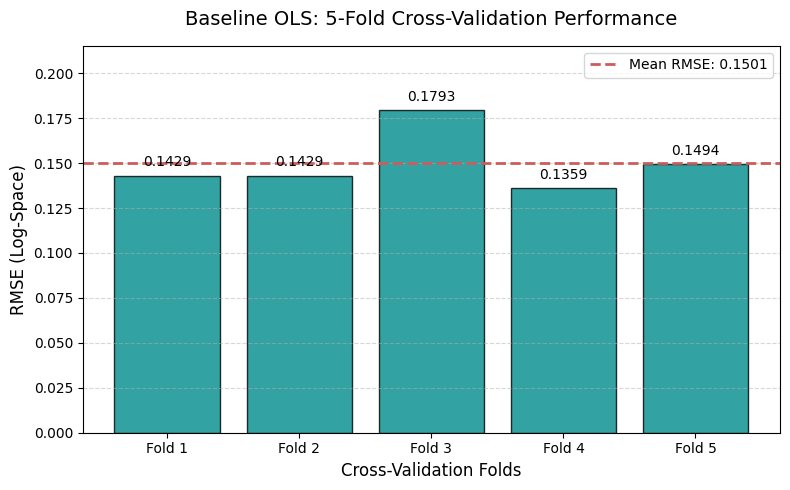

In [245]:
# 確保 rmse_scores 已經從上面的程式碼算出來了
folds = [f"Fold {i+1}" for i in range(len(rmse_scores))]
mean_rmse = baseline_rmse_scores

plt.figure(figsize=(8, 5))

# 畫出每一折 (Fold) 的長條圖
bars = plt.bar(folds, rmse_scores, color='darkcyan', alpha=0.8, edgecolor='black')

# 畫出紅色的平均值虛線
plt.axhline(y=mean_rmse, color='indianred', linestyle='--', linewidth=2, label=f'Mean RMSE: {mean_rmse:.4f}')

# 設定標題與標籤
plt.title('Baseline OLS: 5-Fold Cross-Validation Performance', fontsize=14, pad=15)
plt.xlabel('Cross-Validation Folds', fontsize=12)
plt.ylabel('RMSE (Log-Space)', fontsize=12)

# 在長條圖上方標註具體數字
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + (max(rmse_scores)*0.02), 
             f'{yval:.4f}', ha='center', va='bottom', fontsize=10)

# 調整圖表外觀
plt.ylim(0, max(rmse_scores) * 1.2) # 留出上方空間給數字
plt.legend(loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

# 儲存圖片 (為了放進報告)
plt.savefig('baseline_cv_scores.png', dpi=300)
plt.show()

In [246]:
# 1. 建立一個全新的模型實例
baseline_model = LinearRegression()

# 2. 用「全部的研發集」進行訓練 (不再切 Fold，梭哈 90% 的資料)
baseline_model.fit(X_dev_scaled, y_dev)

# 3. 預測「鎖在保險箱」裡的 10% 測試集
# 這是模型第一次見到這些資料，最能反應真實實力
baseline_preds = baseline_model.predict(X_final_test_scaled)

# 4. 計算最終 Test RMSE (對數空間)
# 使用你之前定義的 rmse_log 函數
baseline_test_rmse = rmse_log(y_final_test, baseline_preds)

print("--- 終極期末考成績 (Baseline Test Error) ---")
print(f"Baseline Test RMSE (Log-Space): {baseline_test_rmse:.4f}")

# 如果你想看換算成美金大約是多少誤差百分比
print(f"Basline Mean Percentage Error: {(np.exp(baseline_test_rmse) - 1)*100:.2f}%")

--- 終極期末考成績 (Baseline Test Error) ---
Baseline Test RMSE (Log-Space): 0.2445
Basline Mean Percentage Error: 27.69%


<>:16: SyntaxWarning: invalid escape sequence '\h'
<>:16: SyntaxWarning: invalid escape sequence '\h'
C:\Users\j1456\AppData\Local\Temp\ipykernel_19140\3623660971.py:16: SyntaxWarning: invalid escape sequence '\h'
  label='Perfect Prediction ($y = \hat{y}$)')


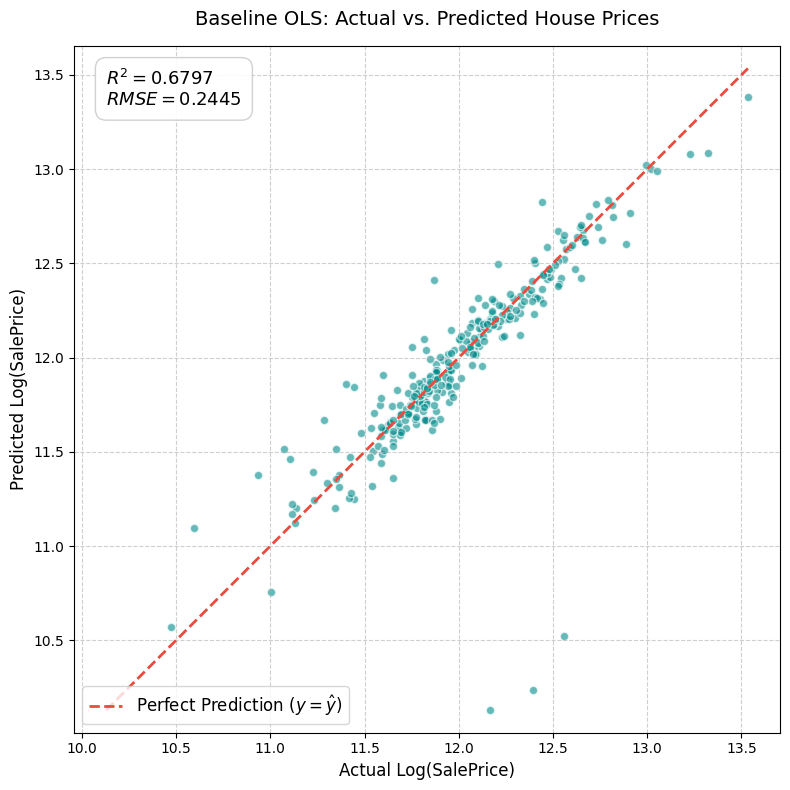

In [247]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error
baseline_r2 = r2_score(y_final_test, baseline_preds)
baseline_rmse = np.sqrt(mean_squared_error(y_final_test, baseline_preds)) # 可選

plt.figure(figsize=(8, 8)) # 設為正方形比較好觀察 45 度線

# 1. 畫出每一個預測點 (使用 mediumpurple 區分其他模型)
plt.scatter(y_final_test, baseline_preds, alpha=0.6, color='darkcyan', edgecolor='white')

# 2. 畫出完美的 45 度對角線 (基準線)
min_val = min(np.min(y_final_test), np.min(baseline_preds))
max_val = max(np.max(y_final_test), np.max(baseline_preds))
plt.plot([min_val, max_val], [min_val, max_val], 
         color='#E74C3C', linestyle='--', linewidth=2, 
         label='Perfect Prediction ($y = \hat{y}$)')

# 3. 設定標題與標籤
plt.title('Baseline OLS: Actual vs. Predicted House Prices', fontsize=14, pad=15)
plt.xlabel('Actual Log(SalePrice)', fontsize=12)
plt.ylabel('Predicted Log(SalePrice)', fontsize=12)

plt.text(min_val, max_val, f'$R^2 = {baseline_r2:.4f}$\n$RMSE = {baseline_rmse:.4f}$',
         fontsize=13, verticalalignment='top',
         bbox=dict(boxstyle='round,pad=0.6', facecolor='white', alpha=0.9, edgecolor='#ccc'))

# 6. 調整視覺細節
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='lower left', fontsize=12)
plt.axis('equal') # 🌟 關鍵：強制 X 軸和 Y 軸比例一致，這樣 45 度線才不會變形
plt.tight_layout()

# 🌟 4. 在圖表中加入 R^2 和 RMSE 文字 (例如左上角，調整坐標和樣式)
# 這裡使用 bbox 給文字加上圓角邊框和白色背景，使其更清晰且不被遮擋
plt.show()

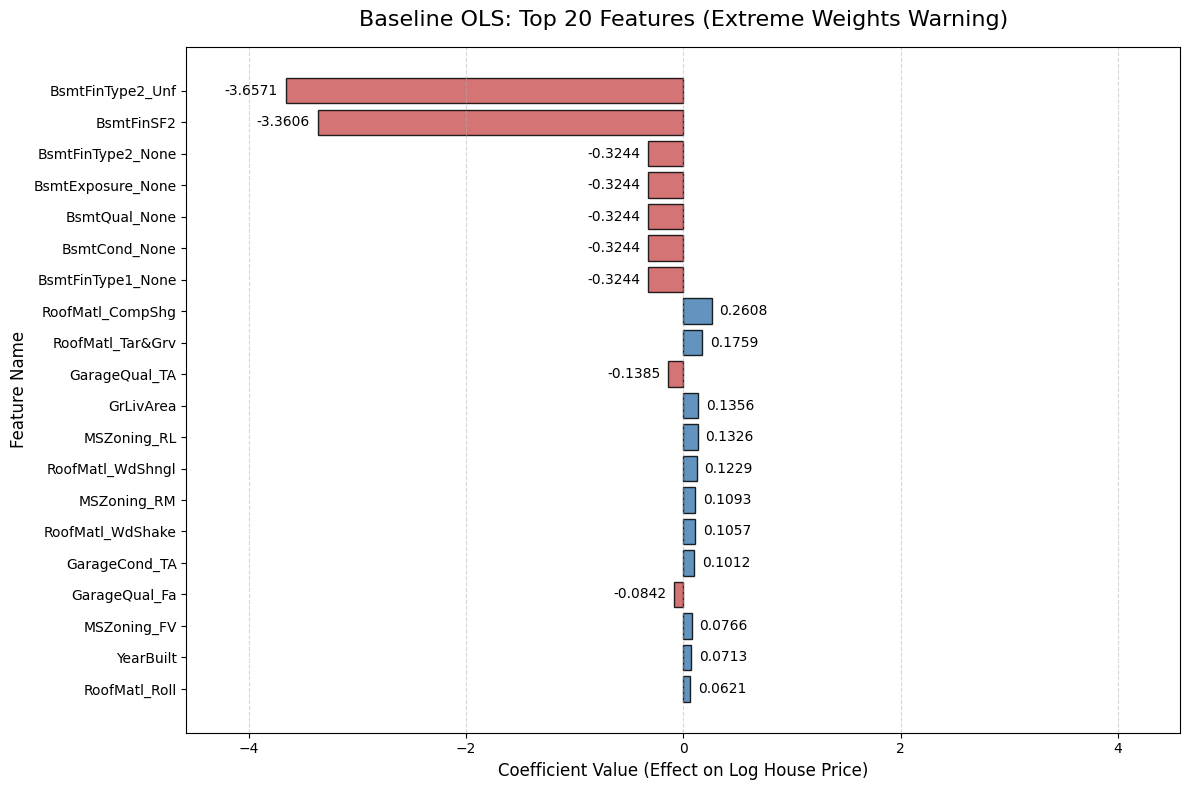

In [274]:
ols_coefs = baseline_model.coef_  
feature_names = X_dev_scaled.columns 

# 2. 建立 DataFrame 並計算絕對值 (這樣才能不分正負，抓出影響力最強的)
ols_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': ols_coefs,
    'Abs_Coefficient': np.abs(ols_coefs)
})

# 3. 抓出絕對值最大的前 20 個特徵
top_20_ols = ols_df.sort_values(by='Abs_Coefficient', ascending=False).head(20)

# 🌟 關鍵修正：將這 20 筆資料的順序「上下顛倒」
# 這樣最大的值就會跑到最後面，plt.barh 就會把它畫在最上方！
top_20_ols = top_20_ols.iloc[::-1]

# 4. 繪製精美的正負雙色長條圖
plt.figure(figsize=(12, 8))

# 設定顏色：正值用學術藍，負值用磚紅 (保持與你前面 Ridge 圖表的邏輯一致)
colors = ['indianred' if c < 0 else 'steelblue' for c in top_20_ols['Coefficient']]

bars = plt.barh(top_20_ols['Feature'], top_20_ols['Coefficient'], 
                color=colors, edgecolor='black', alpha=0.85)

plt.title('Baseline OLS: Top 20 Features (Extreme Weights Warning)', fontsize=16, pad=15)
plt.xlabel('Coefficient Value (Effect on Log House Price)', fontsize=12)
plt.ylabel('Feature Name', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)

# 5. 加上數值標籤 (自動判斷正負值來決定文字放在左邊還是右邊)
max_abs_val = top_20_ols['Abs_Coefficient'].max()
offset = max_abs_val * 0.02 # 留出一點字體緩衝空間

for index, bar in enumerate(bars):
    val = bar.get_width()
    if val < 0:
        plt.text(val - offset, index, f'{val:.4f}', va='center', ha='right', fontsize=10)
    else:
        plt.text(val + offset, index, f'{val:.4f}', va='center', ha='left', fontsize=10)

# 6. 動態延伸 X 軸，確保文字絕對不會被切掉
plt.xlim(-max_abs_val * 1.25, max_abs_val * 1.25)

plt.tight_layout()
plt.show()

Find Lasso and Ridge models alpha

In [249]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.linear_model import Ridge, Lasso



# 1. 自動調參並訓練

# Lasso 喜歡極小的數字 (剛撞到 0.001 的地板)
lasso_alphas = np.logspace(-5, -1, 50)

# Ridge 喜歡大一點的數字 (第一次測出最佳是 5.96)
ridge_alphas = np.logspace(-1, 3, 50)

lasso_cv = LassoCV(alphas=lasso_alphas, cv=kf, max_iter=10000)
ridge_cv = RidgeCV(alphas=ridge_alphas, cv=kf)

print("正在對數空間中尋找最佳 alpha 並訓練模型...")
lasso_cv.fit(X_dev_scaled, y_dev)
ridge_cv.fit(X_dev_scaled, y_dev)

# 2. Ridge 以及 Lasso 模型
# alpha 是「懲罰力度」，數字越大代表我們越嚴格地限制特徵的權重
lasso_model = Lasso(alpha=lasso_cv.alpha_)
ridge_model = Ridge(alpha=ridge_cv.alpha_)

# 3. 進行 5-Fold 交叉驗證
lasso_scores = cross_val_score(lasso_model, X_dev_scaled, y_dev, cv=kf, scoring='neg_mean_squared_error')
ridge_scores = cross_val_score(ridge_model, X_dev_scaled, y_dev, cv=kf, scoring='neg_mean_squared_error')

# 4. 轉換為 RMSE 陣列 (這裡會保留 5 個數字)
lasso_rmse_scores = np.sqrt(np.abs(lasso_scores))
ridge_rmse_scores = np.sqrt(np.abs(ridge_scores))

# 5. 計算平均 RMSE
lasso_mean_rmse = lasso_rmse_scores.mean()
ridge_mean_rmse = ridge_rmse_scores.mean()

print("模型結果")
print("-" * 40)
print(f"Lasso 最佳 alpha: {lasso_cv.alpha_:.4f}")
print(f"Ridge 最佳 alpha: {ridge_cv.alpha_:.4f}")
print("-" * 30)
print(f"1. 一般線性迴歸 (Baseline): {baseline_rmse_scores:.4f}")
print(f"2. Lasso 迴歸模型 RMSE:      {lasso_mean_rmse:.4f}")
print(f"3. Ridge 迴歸模型 RMSE:      {ridge_mean_rmse:.4f}")



正在對數空間中尋找最佳 alpha 並訓練模型...
模型結果
----------------------------------------
Lasso 最佳 alpha: 0.0041
Ridge 最佳 alpha: 268.2696
------------------------------
1. 一般線性迴歸 (Baseline): 0.1501
2. Lasso 迴歸模型 RMSE:      0.1323
3. Ridge 迴歸模型 RMSE:      0.1346


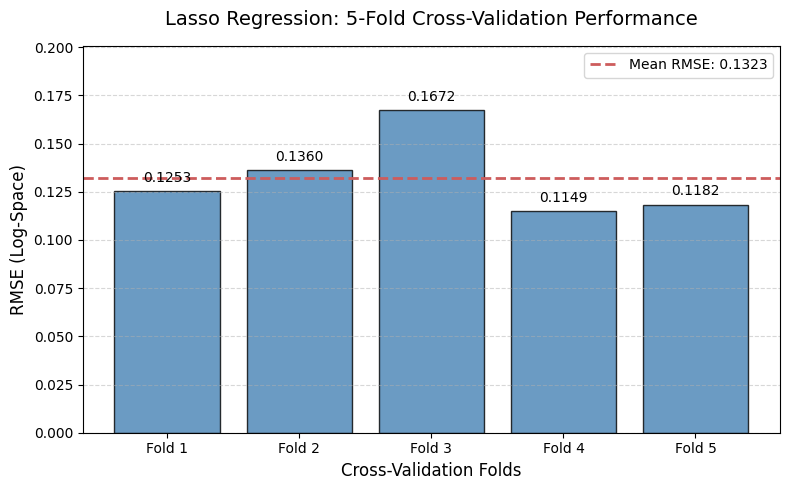

In [250]:
# 確保你已經計算出 lasso_rmse_scores (5折分數陣列) 與 lasso_mean_rmse (平均分數)
folds = [f"Fold {i+1}" for i in range(len(lasso_rmse_scores))]

plt.figure(figsize=(8, 5))

# 1. 畫出每一折 (Fold) 的長條圖 (顏色改為 teal 湖水綠，呼應你的 Lasso 散佈圖)
bars = plt.bar(folds, lasso_rmse_scores, color='steelblue', alpha=0.8, edgecolor='black')

# 2. 畫出紅色的平均值虛線
plt.axhline(y=lasso_mean_rmse, color='indianred', linestyle='--', linewidth=2, label=f'Mean RMSE: {lasso_mean_rmse:.4f}')

# 3. 設定標題與標籤 (更新為 Lasso Regression)
plt.title('Lasso Regression: 5-Fold Cross-Validation Performance', fontsize=14, pad=15)
plt.xlabel('Cross-Validation Folds', fontsize=12)
plt.ylabel('RMSE (Log-Space)', fontsize=12)

# 4. 在長條圖上方標註具體數字
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + (max(lasso_rmse_scores)*0.02), 
             f'{yval:.4f}', ha='center', va='bottom', fontsize=10)

# 5. 調整圖表外觀
plt.ylim(0, max(lasso_rmse_scores) * 1.2) # 留出上方空間給數字
plt.legend(loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

# 6. 儲存圖片 (檔名改為 lasso_cv_scores.png)
plt.savefig('lasso_cv_scores.png', dpi=300, bbox_inches='tight')
plt.show()

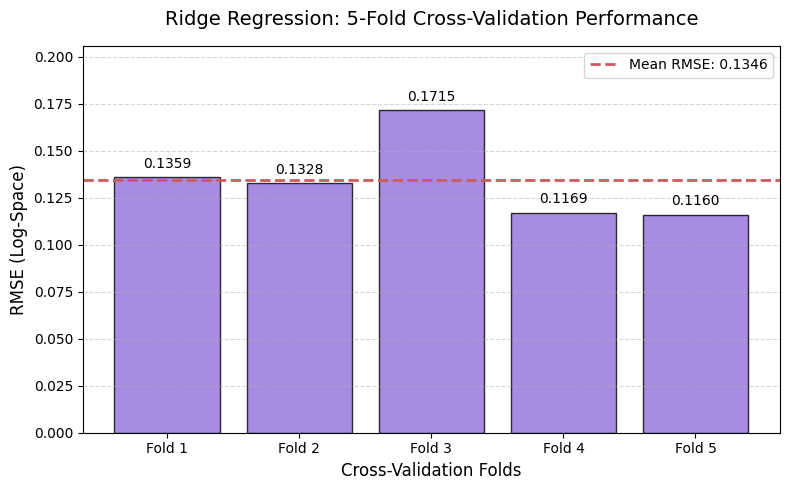

In [251]:
# 確保已經有 ridge_rmse_scores (5個數字的陣列) 與 ridge_mean_rmse (平均值)
folds = [f"Fold {i+1}" for i in range(len(ridge_rmse_scores))]

plt.figure(figsize=(8, 5))

# 1. 畫出每一折 (Fold) 的長條圖 (顏色保持 steelblue 不變)
bars = plt.bar(folds, ridge_rmse_scores, color='mediumpurple', alpha=0.8, edgecolor='black')

# 2. 畫出紅色的平均值虛線 (顏色保持 indianred 不變)
plt.axhline(y=ridge_mean_rmse, color='indianred', linestyle='--', linewidth=2, label=f'Mean RMSE: {ridge_mean_rmse:.4f}')

# 3. 設定標題與標籤 (更新為 Ridge Regression)
plt.title('Ridge Regression: 5-Fold Cross-Validation Performance', fontsize=14, pad=15)
plt.xlabel('Cross-Validation Folds', fontsize=12)
plt.ylabel('RMSE (Log-Space)', fontsize=12)

# 4. 在長條圖上方標註具體數字
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + (max(ridge_rmse_scores)*0.02), 
             f'{yval:.4f}', ha='center', va='bottom', fontsize=10)

# 5. 調整圖表外觀
plt.ylim(0, max(ridge_rmse_scores) * 1.2) # 留出上方空間給數字
plt.legend(loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

# 6. 儲存圖片 (檔名改為 ridge_cv_scores.png)
plt.savefig('ridge_cv_scores.png', dpi=300, bbox_inches='tight')
plt.show()

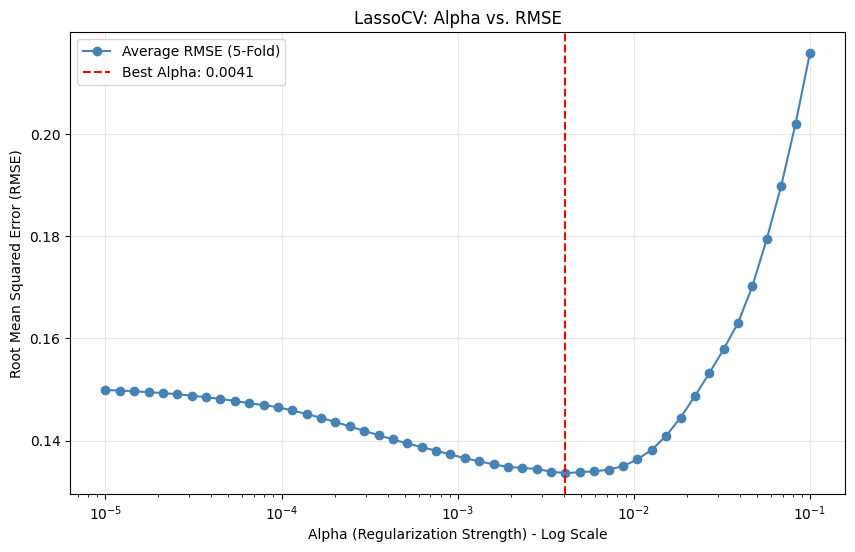

In [252]:
import matplotlib.pyplot as plt

# lasso_cv.mse_path_ 是一個矩陣 (50個 alpha x 5折交叉驗證)
# 我們沿著折數 (axis=1) 取平均，得到每個 alpha 的平均 MSE
mse_mean = lasso_cv.mse_path_.mean(axis=1)

# 為了方便對照，我們把 MSE 開根號變成 RMSE
rmse_mean = np.sqrt(mse_mean)

plt.figure(figsize=(10, 6))

# 畫出 Alpha 與 平均 RMSE 的曲線
# 注意：lasso_cv.alphas_ 存放著你設定的那 50 個 alpha 值
plt.plot(lasso_cv.alphas_, rmse_mean, marker='o', linestyle='-', color='steelblue', label='Average RMSE (5-Fold)')

# 畫一條垂直的紅虛線，標示出我們找到的「最佳 Alpha」
plt.axvline(lasso_cv.alpha_, color='r', linestyle='--', label=f'Best Alpha: {lasso_cv.alpha_:.4f}')

# 設定 X 軸為對數刻度 (因為你的 alpha 是用 logspace 產生的)
plt.xscale('log')

plt.title('LassoCV: Alpha vs. RMSE')
plt.xlabel('Alpha (Regularization Strength) - Log Scale')
plt.ylabel('Root Mean Squared Error (RMSE)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

正在計算 Ridge 在不同 Alpha 下的 RMSE，請稍候...


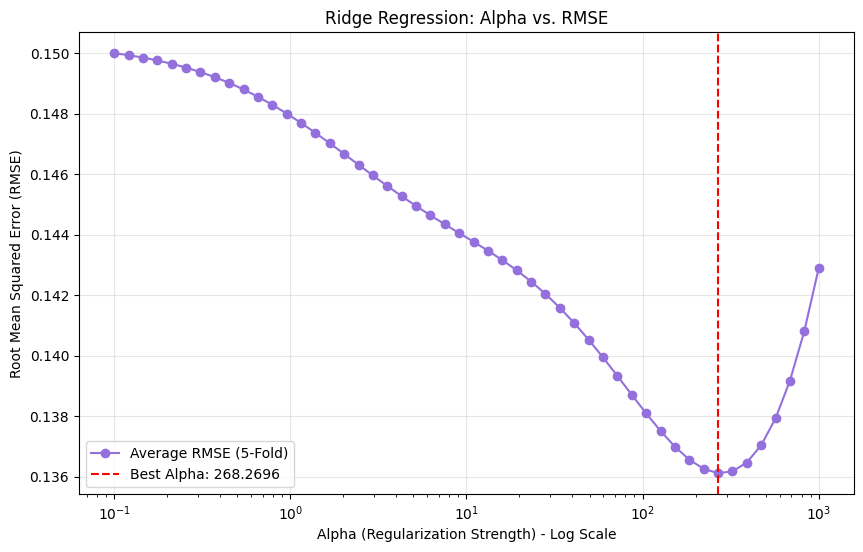

In [253]:
ridge_rmse_path = []

print("正在計算 Ridge 在不同 Alpha 下的 RMSE，請稍候...")
# ridge_alphas 是你之前設定的 np.logspace(-1, 3, 50)
for a in ridge_alphas:
    model = Ridge(alpha=a)
    # 使用完全一樣的 kf 考卷，確保公平
    scores = cross_val_score(model, X_dev_scaled, y_dev, cv=kf, scoring='neg_mean_squared_error')
    # 計算這組 alpha 的平均 RMSE 並存入清單
    mean_rmse = np.sqrt(np.abs(scores).mean())
    ridge_rmse_path.append(mean_rmse)

# ==========================================
# 2. 繪製 Alpha vs. RMSE 曲線
# ==========================================
plt.figure(figsize=(10, 6))

# 畫出曲線
plt.plot(ridge_alphas, ridge_rmse_path, marker='o', linestyle='-', color='mediumpurple', label='Average RMSE (5-Fold)')

# 畫一條垂直的紅虛線，標示出我們之前用 RidgeCV 找到的「最佳 Alpha」
plt.axvline(ridge_cv.alpha_, color='r', linestyle='--', label=f'Best Alpha: {ridge_cv.alpha_:.4f}')

# 設定 X 軸為對數刻度
plt.xscale('log')

plt.title('Ridge Regression: Alpha vs. RMSE')
plt.xlabel('Alpha (Regularization Strength) - Log Scale')
plt.ylabel('Root Mean Squared Error (RMSE)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [254]:
lasso_model.fit(X_dev_scaled, y_dev)

lasso_preds = lasso_model.predict(X_final_test_scaled)

lasso_test_rmse = rmse_log(y_final_test, lasso_preds)

ridge_model.fit(X_dev_scaled, y_dev)

ridge_preds = ridge_model.predict(X_final_test_scaled)

ridge_test_rmse = rmse_log(y_final_test, ridge_preds)

print("--- ( Test Error) ---")
print(f"Baseline Test RMSE (Log-Space): {baseline_test_rmse:.4f}")
print(f"Lasso Test RMSE (Log-Space): {lasso_test_rmse:.4f}")
print(f"Ridge Test RMSE (Log-Space): {ridge_test_rmse:.4f}")
print("="*40)
print(f"Basline Mean Percentage Error: {(np.exp(baseline_test_rmse) - 1)*100:.2f}%")
print(f"Lasso Mean Percentage Error: {(np.exp(lasso_test_rmse) - 1)*100:.2f}%")
print(f"Ridge Mean Percentage Error: {(np.exp(ridge_test_rmse) - 1)*100:.2f}%")

--- ( Test Error) ---
Baseline Test RMSE (Log-Space): 0.2445
Lasso Test RMSE (Log-Space): 0.1352
Ridge Test RMSE (Log-Space): 0.1421
Basline Mean Percentage Error: 27.69%
Lasso Mean Percentage Error: 14.48%
Ridge Mean Percentage Error: 15.27%


<>:14: SyntaxWarning: invalid escape sequence '\h'
<>:14: SyntaxWarning: invalid escape sequence '\h'
C:\Users\j1456\AppData\Local\Temp\ipykernel_19140\3679287678.py:14: SyntaxWarning: invalid escape sequence '\h'
  label='Perfect Prediction ($y = \hat{y}$)')


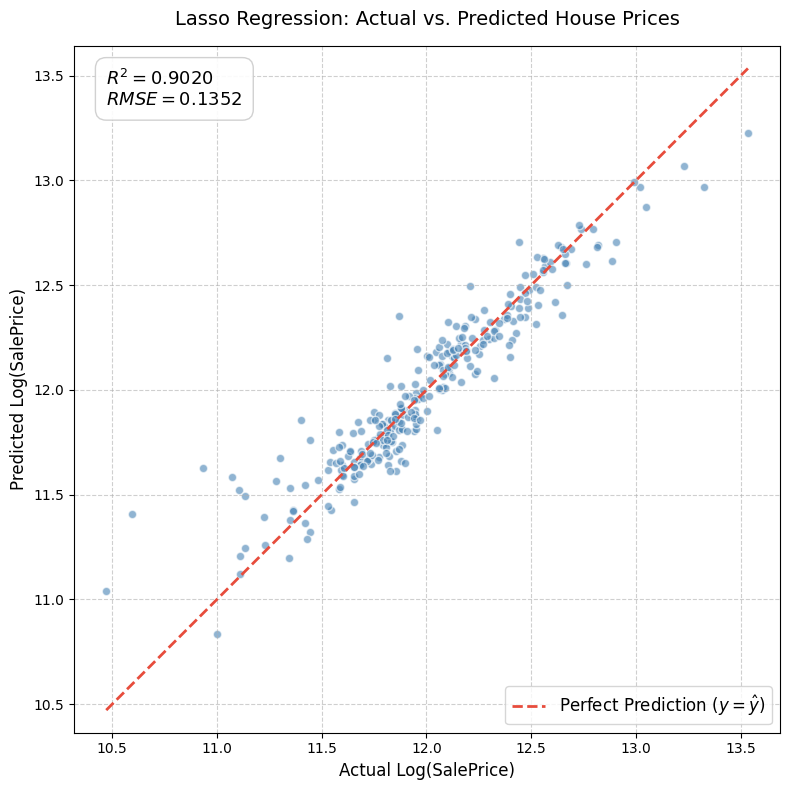

In [255]:

lasso_r2 = r2_score(y_final_test, lasso_preds)
lasso_rmse = np.sqrt(mean_squared_error(y_final_test, lasso_preds)) # 可選

plt.figure(figsize=(8, 8)) # 設為正方形比較好觀察 45 度線

# 1. 畫出每一個預測點 (使用 mediumpurple 區分其他模型)
plt.scatter(y_final_test, ridge_preds, alpha=0.6, color='steelblue', edgecolor='white')

# 2. 畫出完美的 45 度對角線 (基準線)
min_val = min(np.min(y_final_test), np.min(ridge_preds))
max_val = max(np.max(y_final_test), np.max(ridge_preds))
plt.plot([min_val, max_val], [min_val, max_val], 
         color='#E74C3C', linestyle='--', linewidth=2, 
         label='Perfect Prediction ($y = \hat{y}$)')

# 3. 設定標題與標籤
plt.title('Lasso Regression: Actual vs. Predicted House Prices', fontsize=14, pad=15)
plt.xlabel('Actual Log(SalePrice)', fontsize=12)
plt.ylabel('Predicted Log(SalePrice)', fontsize=12)

plt.text(min_val, max_val, f'$R^2 = {lasso_r2:.4f}$\n$RMSE = {lasso_rmse:.4f}$',
         fontsize=13, verticalalignment='top',
         bbox=dict(boxstyle='round,pad=0.6', facecolor='white', alpha=0.9, edgecolor='#ccc'))

# 6. 調整視覺細節
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='lower right', fontsize=12)
plt.axis('equal') # 🌟 關鍵：強制 X 軸和 Y 軸比例一致，這樣 45 度線才不會變形
plt.tight_layout()

# 🌟 4. 在圖表中加入 R^2 和 RMSE 文字 (例如左上角，調整坐標和樣式)
# 這裡使用 bbox 給文字加上圓角邊框和白色背景，使其更清晰且不被遮擋
plt.show()

<>:15: SyntaxWarning: invalid escape sequence '\h'
<>:15: SyntaxWarning: invalid escape sequence '\h'
C:\Users\j1456\AppData\Local\Temp\ipykernel_19140\2916649246.py:15: SyntaxWarning: invalid escape sequence '\h'
  label='Perfect Prediction ($y = \hat{y}$)')


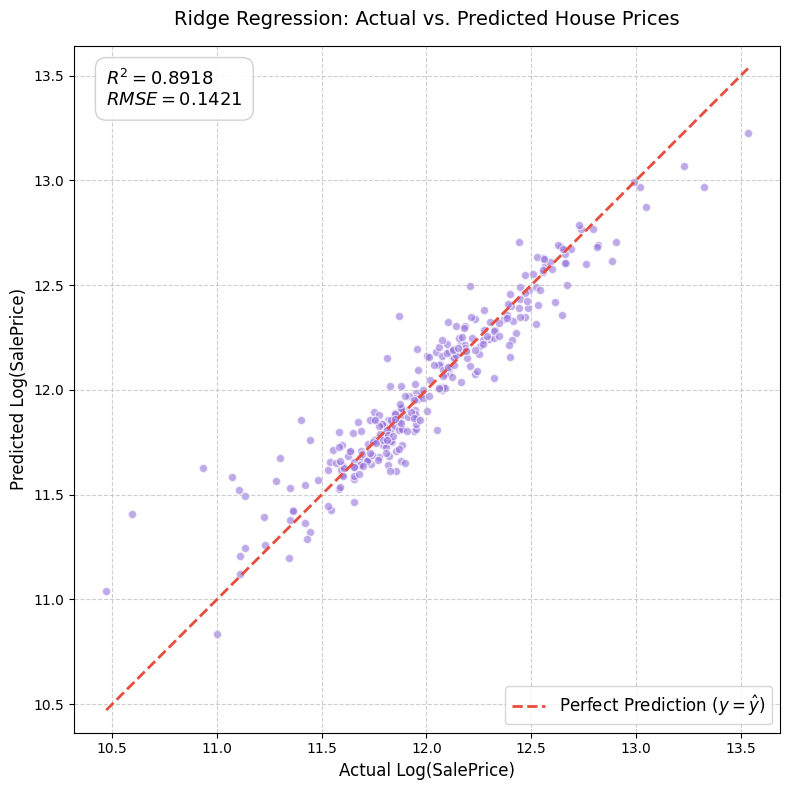

In [256]:

# 在這裡計算 R^2 和 RMSE (可選，如果您想同時加入)
ridge_r2 = r2_score(y_final_test, ridge_preds)
ridge_rmse = np.sqrt(mean_squared_error(y_final_test, ridge_preds)) # 可選

plt.figure(figsize=(8, 8)) # 設為正方形比較好觀察 45 度線

# 1. 畫出每一個預測點 (使用 mediumpurple 區分其他模型)
plt.scatter(y_final_test, ridge_preds, alpha=0.6, color='mediumpurple', edgecolor='white')

# 2. 畫出完美的 45 度對角線 (基準線)
min_val = min(np.min(y_final_test), np.min(ridge_preds))
max_val = max(np.max(y_final_test), np.max(ridge_preds))
plt.plot([min_val, max_val], [min_val, max_val], 
         color='#E74C3C', linestyle='--', linewidth=2, 
         label='Perfect Prediction ($y = \hat{y}$)')

# 3. 設定標題與標籤
plt.title('Ridge Regression: Actual vs. Predicted House Prices', fontsize=14, pad=15)
plt.xlabel('Actual Log(SalePrice)', fontsize=12)
plt.ylabel('Predicted Log(SalePrice)', fontsize=12)

plt.text(min_val, max_val, f'$R^2 = {ridge_r2:.4f}$\n$RMSE = {ridge_rmse:.4f}$',
         fontsize=13, verticalalignment='top',
         bbox=dict(boxstyle='round,pad=0.6', facecolor='white', alpha=0.9, edgecolor='#ccc'))

# 6. 調整視覺細節
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='lower right', fontsize=12)
plt.axis('equal') # 🌟 關鍵：強制 X 軸和 Y 軸比例一致，這樣 45 度線才不會變形
plt.tight_layout()

# 🌟 4. 在圖表中加入 R^2 和 RMSE 文字 (例如左上角，調整坐標和樣式)
# 這裡使用 bbox 給文字加上圓角邊框和白色背景，使其更清晰且不被遮擋
plt.show()

In [257]:

# ==========================================
# 1. 取得資料並建立 DataFrame
# ==========================================
features = X.columns
lasso_coefs = lasso_model.coef_

lasso_coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': lasso_coefs,
    'Abs_Coefficient': np.abs(lasso_coefs)
})

# ==========================================
# 2. 篩選：區分「存活」與「淘汰」特徵
# ==========================================
lasso_dropped = lasso_coef_df[lasso_coef_df['Coefficient'] == 0]
lasso_kept = lasso_coef_df[lasso_coef_df['Coefficient'] != 0]

# ==========================================
# 3. 輸出報告：整體統計
# ==========================================
print("="*60)
print(" Lasso 模型特徵篩選與影響力報告")
print("="*60)
print(f" 總特徵數量: {len(features)}")
print(f" 被 Lasso 砍掉的特徵數量: {len(lasso_dropped)} (權重歸零)")
print(f" 成功保留的特徵數量: {len(lasso_kept)}")
print("-" * 60)

# ==========================================
# 4. 輸出報告：最強 Top 20 特徵排行榜
# ==========================================
if not lasso_kept.empty:
    top_20_lasso_features = lasso_kept.sort_values(by='Abs_Coefficient', ascending=False).head(20)
    print("\n 影響房價【最大】的前 20 個關鍵特徵:")
    print(top_20_lasso_features[['Feature', 'Coefficient']].to_string(index=False))

print("\n" + "="*60)

 Lasso 模型特徵篩選與影響力報告
 總特徵數量: 250
 被 Lasso 砍掉的特徵數量: 158 (權重歸零)
 成功保留的特徵數量: 92
------------------------------------------------------------

 影響房價【最大】的前 20 個關鍵特徵:
             Feature  Coefficient
           GrLivArea     0.123166
         OverallQual     0.078564
           YearBuilt     0.052821
             LotArea     0.038679
         OverallCond     0.038552
          GarageCars     0.038293
          BsmtFinSF1     0.025310
Neighborhood_NridgHt     0.023488
        YearRemodAdd     0.020334
     Condition2_PosN    -0.018451
        BsmtFullBath     0.017177
            1stFlrSF     0.016792
Neighborhood_StoneBr     0.016510
      Functional_Typ     0.016455
          Fireplaces     0.016202
Neighborhood_Crawfor     0.015911
 Exterior1st_BrkFace     0.015481
     Condition1_Norm     0.013232
        CentralAir_Y     0.011982
         TotalBsmtSF     0.011600



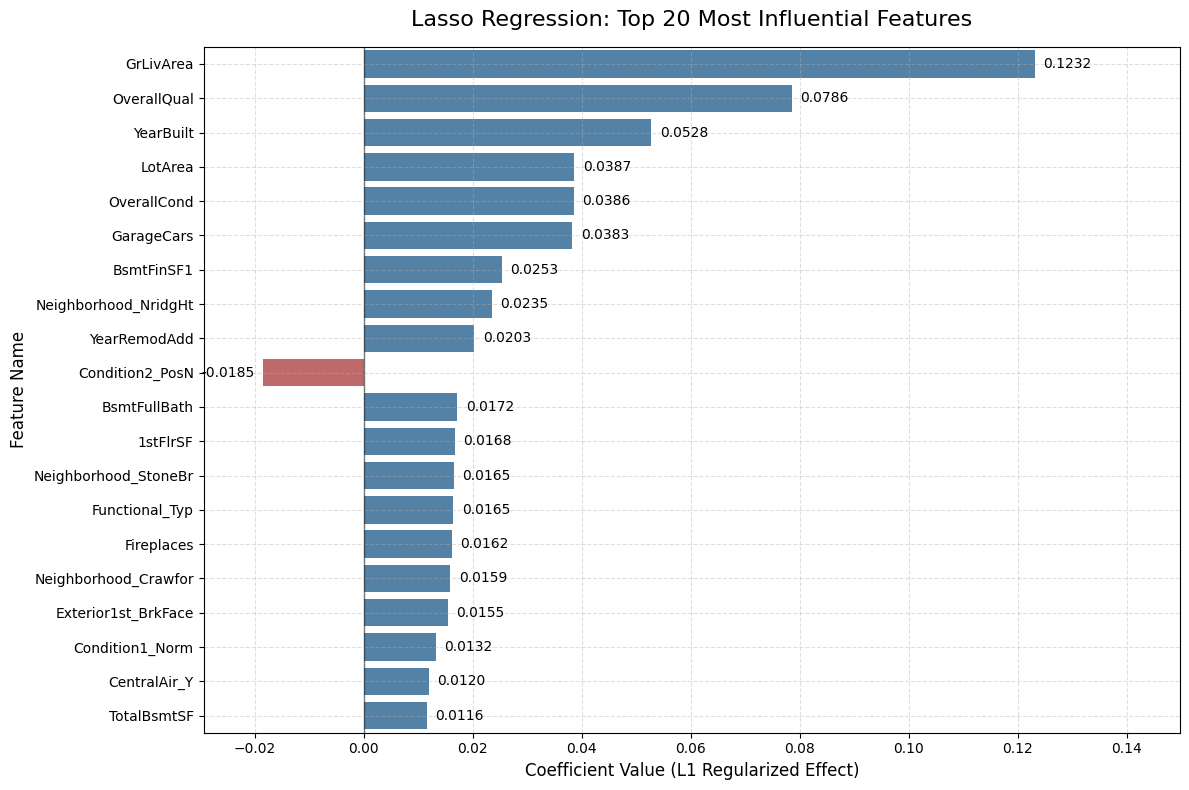

📊 Lasso 統計摘要：
1. 成功生存特徵：92 個
2. 自動過濾特徵：158 個


In [258]:
# ==========================================
# 1. 準備繪圖資料 (延續你剛篩選好的 top_20_lasso_features)
# ==========================================
# 確保我們有依照絕對值大小排序，這樣圖表才會有由大到小的美感
lasso_plot_data = top_20_lasso_features.sort_values(by='Abs_Coefficient', ascending=False)

# 設定顏色：正值(加分)用藍色，負值(扣分)用紅色
lasso_plot_data['Color'] = ['Pos' if x > 0 else 'Neg' for x in lasso_plot_data['Coefficient']]

# ==========================================
# 2. 繪製圖表
# ==========================================
plt.figure(figsize=(12, 8))

# 使用 hue 來區分影響方向
sns.barplot(
    x='Coefficient', 
    y='Feature', 
    data=lasso_plot_data,
    palette={'Pos': 'steelblue', 'Neg': 'indianred'},
    hue='Color',
    legend=False
)

plt.title('Lasso Regression: Top 20 Most Influential Features', fontsize=16, pad=15)
plt.xlabel('Coefficient Value (L1 Regularized Effect)', fontsize=12)
plt.ylabel('Feature Name', fontsize=12)

# 加上 0 位準線，強化對比感
plt.axvline(x=0, color='black', linestyle='-', lw=1, alpha=0.5)

# ==========================================
# 🛠️ 關鍵修改區：解決文字重疊與邊緣切斷問題
# ==========================================
# 1. 取得當前 X 軸的最大與最小值範圍
x_min, x_max = plt.xlim()

# 2. 把左右邊界都稍微撐開 15%，留空間給文字 (才不會被畫面切掉)
plt.xlim(x_min * 1.15 if x_min < 0 else x_min, x_max * 1.15)

# 3. 動態計算一個剛好佔據畫面寬度 1% 的微小間距
offset = (x_max - x_min) * 0.01 

# 4. 加上數值標籤 (根據正負值動態改變對齊方向)
for index, value in enumerate(lasso_plot_data['Coefficient']):
    if value > 0:
        # 正值：文字放在長條圖右側，向右對齊 (ha='left')
        plt.text(value + offset, index, f'{value:.4f}', va='center', ha='left', fontsize=10)
    else:
        # 負值：文字放在長條圖左側，向左對齊 (ha='right')
        plt.text(value - offset, index, f'{value:.4f}', va='center', ha='right', fontsize=10)

plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()

# 儲存圖片 (準備放進 LaTeX，bbox_inches='tight' 確保連邊界外側的標籤也被完整存下)
plt.show()

print(f"📊 Lasso 統計摘要：")
print(f"1. 成功生存特徵：{len(lasso_kept)} 個")
print(f"2. 自動過濾特徵：{len(lasso_dropped)} 個")

In [259]:
# 建立 Ridge 的 DataFrame
features = X.columns
ridge_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': ridge_model.coef_,
    'Abs_Coef': np.abs(ridge_model.coef_)
})

# ==========================================
# ★ 關鍵新增：設定 Ridge 的「實用零值」閥值
# ==========================================
threshold = 0.001  # 你可以根據你的資料尺度調整這個數字 (例如 1e-3 或 1e-4)

# 篩選出大於/小於閥值的特徵
ridge_insignificant = ridge_df[ridge_df['Abs_Coef'] < threshold]
ridge_significant = ridge_df[ridge_df['Abs_Coef'] >= threshold]

print("="*60)
print(" [Ridge 模型] 閥值淘汰分析 (Thresholding)")
print("="*60)
print(f" 總特徵數量: {len(features)}")
print(f" 設定的淘汰閥值 (Threshold): {threshold}")
print(f" 被視為【無影響力】的特徵數量 (絕對值 < 閥值): {len(ridge_insignificant)} 個")
print(f" 實質【保留】的特徵數量 (絕對值 >= 閥值): {len(ridge_significant)} 個")
print("-" * 60)

# 印出那些「倖存」且影響力最大的前 20 名
if not ridge_significant.empty:
    ridge_top20 = ridge_significant.sort_values(by='Abs_Coef', ascending=False).head(20)
    print("\n 實質影響力【最大】的前 20 個關鍵特徵:")
    print(ridge_top20[['Feature', 'Coefficient']].to_string(index=False))
print("="*60)

 [Ridge 模型] 閥值淘汰分析 (Thresholding)
 總特徵數量: 250
 設定的淘汰閥值 (Threshold): 0.001
 被視為【無影響力】的特徵數量 (絕對值 < 閥值): 38 個
 實質【保留】的特徵數量 (絕對值 >= 閥值): 212 個
------------------------------------------------------------

 實質影響力【最大】的前 20 個關鍵特徵:
             Feature  Coefficient
           GrLivArea     0.048980
         OverallQual     0.047840
            1stFlrSF     0.033533
         OverallCond     0.029084
             LotArea     0.025921
          GarageCars     0.024043
Neighborhood_NridgHt     0.021278
         TotalBsmtSF     0.020696
        YearRemodAdd     0.019867
        TotRmsAbvGrd     0.019344
Neighborhood_StoneBr     0.018920
        CentralAir_Y     0.017957
            FullBath     0.017855
           YearBuilt     0.017554
         BsmtQual_TA    -0.017371
            HalfBath     0.017233
Neighborhood_Crawfor     0.017099
          BsmtFinSF1     0.016383
     Condition2_PosN    -0.016156
          GarageArea     0.015883


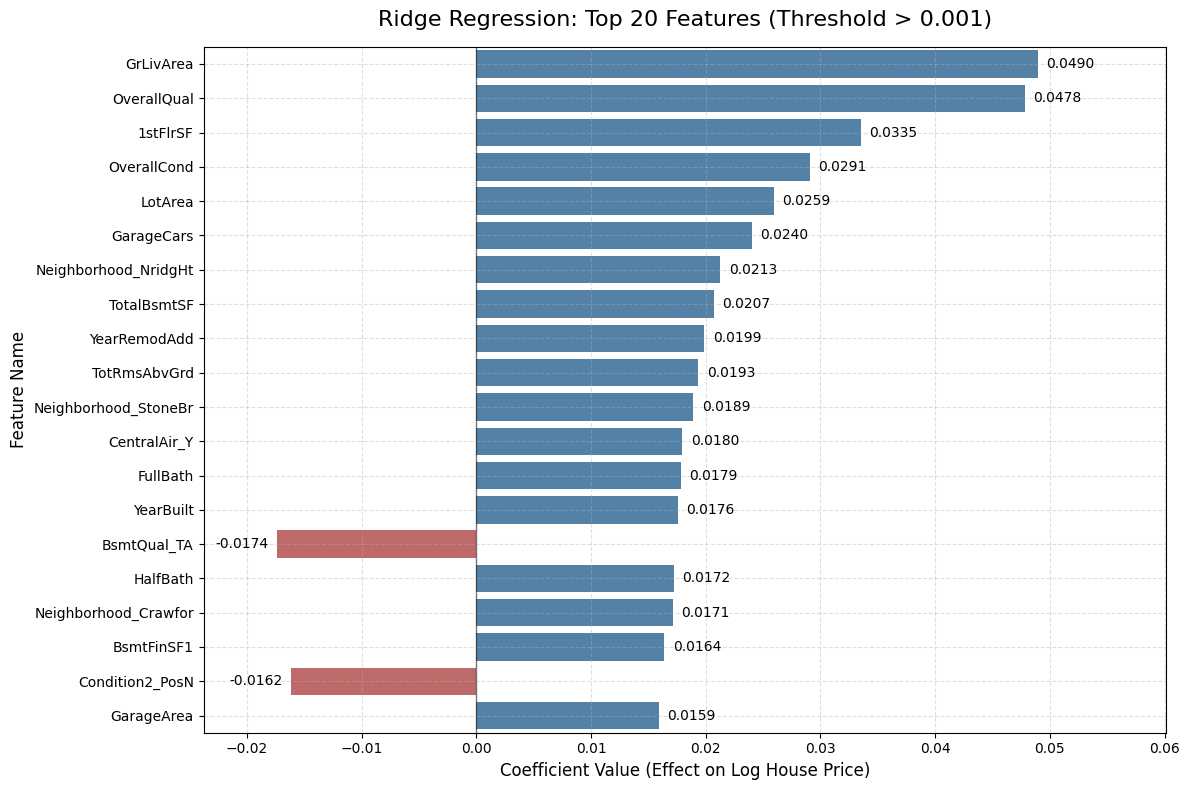

💡 觀察指南：
1. 藍色長條：代表該特徵對房價有『正向提升』作用。
2. 紅色長條：代表該特徵對房價有『負向抑制』作用（常見於屋齡、損壞等）。


In [260]:
# ==========================================
# 1. 準備繪圖資料 (延續你剛寫好的 ridge_top20)
# ==========================================
# 我們取絕對值前 20 名來畫圖，這樣才能看到最強的影響力
ridge_plot_data = ridge_significant.sort_values(by='Abs_Coef', ascending=False).head(20)

# 設定顏色：正值給一個顏色，負值給另一個顏色 (區分房價增減)
ridge_plot_data['Color'] = ['Pos' if x > 0 else 'Neg' for x in ridge_plot_data['Coefficient']]

# ==========================================
# 2. 繪製圖表
# ==========================================
plt.figure(figsize=(12, 8))

# 使用 hue 來區分正負影響力
sns.barplot(
    x='Coefficient', 
    y='Feature', 
    data=ridge_plot_data,
    palette={'Pos': 'steelblue', 'Neg': 'indianred'},
    hue='Color',
    legend=False
)

plt.title('Ridge Regression: Top 20 Features (Threshold > 0.001)', fontsize=16, pad=15)
plt.xlabel('Coefficient Value (Effect on Log House Price)', fontsize=12)
plt.ylabel('Feature Name', fontsize=12)

# 加上一條 0 的中央垂直線
plt.axvline(x=0, color='black', linestyle='-', lw=1, alpha=0.5)

# ==========================================
# 🛠️ 關鍵修改區：加上數值並解決重疊與邊緣切斷
# ==========================================
# 1. 取得當前 X 軸的最大與最小值範圍
x_min, x_max = plt.xlim()

# 2. 把左右邊界都稍微撐開 15%，留空間給文字
plt.xlim(x_min * 1.15 if x_min < 0 else x_min, x_max * 1.15)

# 3. 動態計算一個剛好佔據畫面寬度 1% 的微小間距
offset = (x_max - x_min) * 0.01 

# 4. 加上數值標籤 (根據正負值動態改變對齊方向)
for index, value in enumerate(ridge_plot_data['Coefficient']):
    if value > 0:
        # 正值向右長，文字向左對齊
        plt.text(value + offset, index, f'{value:.4f}', va='center', ha='left', fontsize=10)
    else:
        # 負值向左長，文字向右對齊
        plt.text(value - offset, index, f'{value:.4f}', va='center', ha='right', fontsize=10)

plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()

plt.show()

print("💡 觀察指南：")
print("1. 藍色長條：代表該特徵對房價有『正向提升』作用。")
print("2. 紅色長條：代表該特徵對房價有『負向抑制』作用（常見於屋齡、損壞等）。")

In [261]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor

param_grid = {
    'n_estimators': [500, 1000],        # 樹的數量
    'learning_rate': [0.01, 0.05, 0.1], # 學習率（步長）
    'max_depth': [3, 4, 5],             # 樹的深度
    'subsample': [0.8, 0.9]             # 採樣比例
}

# 建立基礎模型
gb = GradientBoostingRegressor(random_state=42)

# 設定網格搜尋 (自動做 5-Fold 模擬考)
grid_search = GridSearchCV(
    estimator=gb,
    param_grid=param_grid,
    cv=kf,
    scoring='neg_mean_squared_error',
    n_jobs=-1,  # 使用所有 CPU 核心加速運算
    verbose=2
)

print("正在搜尋最佳參數組合，這可能需要幾分鐘...")
grid_search.fit(X_dev, y_dev)

# ==========================================
# 輸出模擬考 (CV) 結果
# ==========================================
print("\n" + "-" * 40)
print(f" GB 最佳參數組合: {grid_search.best_params_}")
for key, value in grid_search.best_params_.items():
    # 統一格式化：只要是浮點數，就對齊到小數點後 4 位
    if isinstance(value, float) or type(value).__name__ == 'float64':
        print(f"  {key}: {value:.4f}")
    else:
        print(f"  {key}: {value}")

# 直接取用 GridSearchCV 肚子裡算好的最高分數即可
gb_cv_rmse = np.sqrt(np.abs(grid_search.best_score_))
print(f" GB 模擬考平均 RMSE (CV Score): {gb_cv_rmse:.4f}")
print("-" * 40)

# grid_search.best_estimator_ 已經是一個用最佳參數 + 100% X_dev 訓練好模型了！
best_gb_model = grid_search.best_estimator_

gb_final_preds = best_gb_model.predict(X_final_test)
gb_final_test_rmse = rmse_log(y_final_test, gb_final_preds)

print("\n" + "="*40)
print(" Gradient Boosting final test")
print("="*40)
print(f" GB Test RMSE: {gb_final_test_rmse:.4f}")
print(f" GB Mean Percentage Error:   {(np.exp(gb_final_test_rmse) - 1)*100:.2f}%")
print("=" * 40)

正在搜尋最佳參數組合，這可能需要幾分鐘...
Fitting 5 folds for each of 36 candidates, totalling 180 fits

----------------------------------------
 GB 最佳參數組合: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 1000, 'subsample': 0.9}
  learning_rate: 0.0500
  max_depth: 3
  n_estimators: 1000
  subsample: 0.9000
 GB 模擬考平均 RMSE (CV Score): 0.1264
----------------------------------------

 Gradient Boosting final test
 GB Test RMSE: 0.1353
 GB Mean Percentage Error:   14.49%


In [262]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import GradientBoostingRegressor
from scipy.stats import randint, uniform

# ==========================================
# 1. 定義連續的參數空間
# ==========================================
param_dist = {
    'n_estimators': randint(300, 1500),
    'learning_rate': uniform(0.01, 0.09),
    'max_depth': randint(3, 8),
    'subsample': uniform(0.6, 0.4),
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 10)
}

gb = GradientBoostingRegressor(random_state=42)

# ==========================================
# 2. 建立 RandomizedSearchCV 物件
# ==========================================
random_search = RandomizedSearchCV(
    estimator=gb,
    param_distributions=param_dist,
    n_iter=100,             # 盲抽 100 組
    cv=kf,                  # 內部做 5-Fold 模擬考
    scoring='neg_mean_squared_error',
    n_jobs=-1,              # 火力全開
    verbose=2,
    random_state=42
)

print("正在進行 100 次隨機探索，這會花一點時間，請稍候...")
random_search.fit(X_dev, y_dev)


# ==========================================
# 3. 輸出模擬 (CV) 結果
# ==========================================
print("\n" + "-" * 40)
print(" GB 隨機搜尋最佳參數組合:")
for key, value in random_search.best_params_.items():
    if isinstance(value, float) or type(value).__name__ == 'float64':
        print(f"  {key}: {value:.4f}")
    else:
        print(f"  {key}: {value}")
print("-" * 40)

# 直接取用算好的最高分數
gb_random_cv_rmse = np.sqrt(np.abs(random_search.best_score_))
print(f" GB 模擬平均 RMSE (CV Score): {gb_random_cv_rmse:.4f}")
print("-" * 40)



# 拿取已經用最佳參數 + 100% X_dev
best_gb_random_model = random_search.best_estimator_

# 進行 final predict
gb_random_final_preds = best_gb_random_model.predict(X_final_test)
gb_random_final_test_rmse = rmse_log(y_final_test, gb_random_final_preds)

print("\n" + "="*45)
print(" RandomizedSearchCV: GB final test")
print("="*45)
print(f" Final GB Test RMSE (Log-Space): {gb_random_final_test_rmse:.4f}")
print(f" Final GB Mean Percentage Error:          {(np.exp(gb_random_final_test_rmse) - 1)*100:.2f}%")
print("=" * 45)

正在進行 100 次隨機探索，這會花一點時間，請稍候...
Fitting 5 folds for each of 100 candidates, totalling 500 fits

----------------------------------------
 GB 隨機搜尋最佳參數組合:
  learning_rate: 0.0243
  max_depth: 3
  min_samples_leaf: 5
  min_samples_split: 16
  n_estimators: 1308
  subsample: 0.7246
----------------------------------------
 GB 模擬平均 RMSE (CV Score): 0.1249
----------------------------------------

 RandomizedSearchCV: GB final test
 Final GB Test RMSE (Log-Space): 0.1321
 Final GB Mean Percentage Error:          14.13%


In [263]:
print(f"Basline Mean Percentage Error: {(np.exp(baseline_test_rmse) - 1)*100:.2f}%")
print(f"Lasso Mean Percentage Error: {(np.exp(lasso_test_rmse) - 1)*100:.2f}%")
print(f"Ridge Mean Percentage Error: {(np.exp(ridge_test_rmse) - 1)*100:.2f}%")
print(f"GB Mean Percentage Error: {(np.exp(gb_final_test_rmse) - 1)*100:.2f}%")
print(f"Final GB Mean Percentage Error: {(np.exp(gb_random_final_test_rmse) - 1)*100:.2f}%")

Basline Mean Percentage Error: 27.69%
Lasso Mean Percentage Error: 14.48%
Ridge Mean Percentage Error: 15.27%
GB Mean Percentage Error: 14.49%
Final GB Mean Percentage Error: 14.13%


Mean RMSE: 0.1237 ± 0.0170


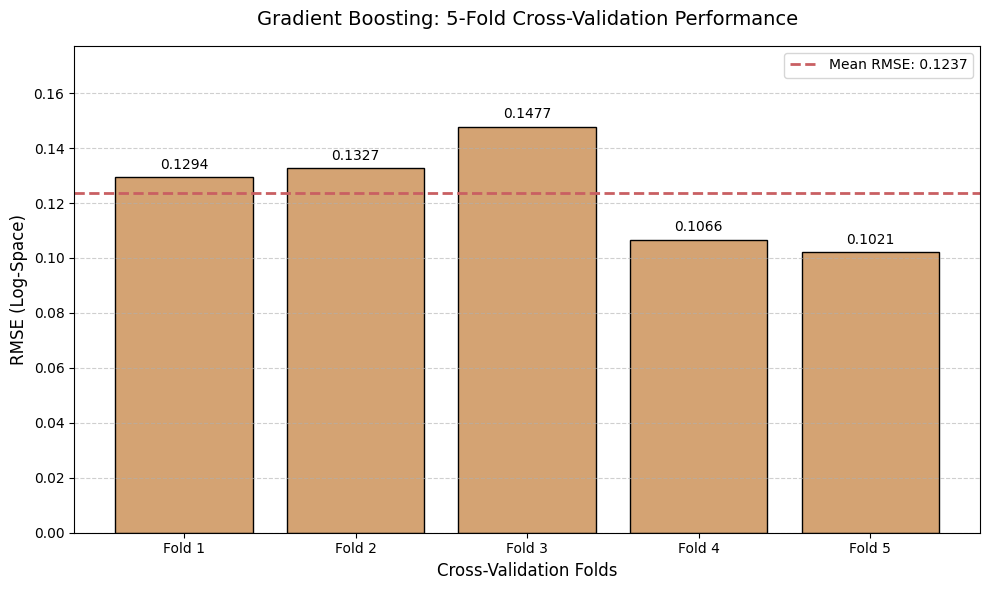

In [264]:
best_index = random_search.best_index_

# 2. 提取這組最佳模型在 5 個 Fold 中的獨立分數
n_splits = 5
fold_scores = []

for i in range(n_splits):
    # 🌟 修正重點：取出負的 MSE，轉正後「開根號」變成 RMSE
    mse_score = -random_search.cv_results_[f'split{i}_test_score'][best_index]
    rmse_score = np.sqrt(mse_score)
    fold_scores.append(rmse_score)

# 3. 計算平均值與標準差 (用來評估 Variance)
mean_rmse = np.mean(fold_scores)
std_rmse = np.std(fold_scores)
print(f"Mean RMSE: {mean_rmse:.4f} ± {std_rmse:.4f}")

# 4. 開始畫圖 (模仿 Lasso 長條圖風格)
folds_labels = [f'Fold {i+1}' for i in range(n_splits)]

plt.figure(figsize=(10, 6))
bars = plt.bar(folds_labels, fold_scores, color="#D4A373", edgecolor='black')

# 畫出平均值的紅色虛線
plt.axhline(y=mean_rmse, color='#c95f62', linestyle='--', linewidth=2, 
            label=f'Mean RMSE: {mean_rmse:.4f}')

# 在每個柱狀圖上方標註確切數值
# (微調了 yval 的加上值，讓數字不會離柱子太遠)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.002, 
             f'{yval:.4f}', ha='center', va='bottom')

# 設定圖表格式
plt.title('Gradient Boosting: 5-Fold Cross-Validation Performance', fontsize=14, pad=15)
plt.ylabel('RMSE (Log-Space)', fontsize=12)
plt.xlabel('Cross-Validation Folds', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.ylim(0, max(fold_scores) * 1.2) # 留一點頂部空間給文字
plt.legend()
plt.tight_layout()

plt.show()

<>:17: SyntaxWarning: invalid escape sequence '\h'
<>:17: SyntaxWarning: invalid escape sequence '\h'
C:\Users\j1456\AppData\Local\Temp\ipykernel_19140\1063207172.py:17: SyntaxWarning: invalid escape sequence '\h'
  label='Perfect Prediction ($y = \hat{y}$)')


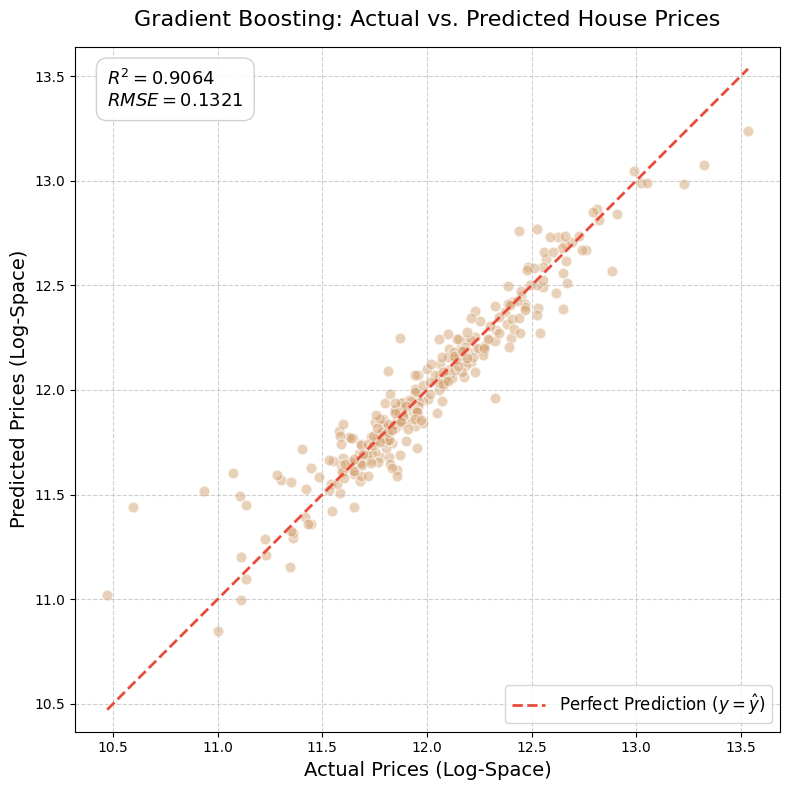

In [265]:

r2 = r2_score(y_final_test, gb_random_final_preds)
rmse = np.sqrt(mean_squared_error(y_final_test, gb_random_final_preds))

# 2. 開始畫圖
plt.figure(figsize=(8, 8)) # 使用正方形畫布，讓 45 度線更直覺

# 畫出預測 vs 真實的散佈圖 (使用半透明 alpha 避免點重疊看不清密度)
plt.scatter(y_final_test, gb_random_final_preds, 
            alpha=0.5, color="#D4A373", edgecolor='white', s=60)

# 3. 畫出 y=x 的「完美預測基準線」
# 找出 X 和 Y 軸的上下限，讓線能完美對齊對角
min_val = min(np.min(y_final_test), np.min(gb_random_final_preds))
max_val = max(np.max(y_final_test), np.max(gb_random_final_preds))
plt.plot([min_val, max_val], [min_val, max_val], 
         color='#E74C3C', linestyle='--', linewidth=2, 
         label='Perfect Prediction ($y = \hat{y}$)')

# 4. 設定圖表標籤與格式
plt.title('Gradient Boosting: Actual vs. Predicted House Prices', fontsize=16, pad=15)
plt.xlabel('Actual Prices (Log-Space)', fontsize=14)
plt.ylabel('Predicted Prices (Log-Space)', fontsize=14)

# 5. 在圖表左上角加上評估指標的文字方塊
plt.text(min_val, max_val, f'$R^2 = {r2:.4f}$\n$RMSE = {rmse:.4f}$',
         fontsize=13, verticalalignment='top',
         bbox=dict(boxstyle='round,pad=0.6', facecolor='white', alpha=0.9, edgecolor='#ccc'))

# 6. 調整視覺細節
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='lower right', fontsize=12)
plt.axis('equal') # 🌟 關鍵：強制 X 軸和 Y 軸比例一致，這樣 45 度線才不會變形
plt.tight_layout()

plt.show()

正在計算 max_depth 的驗證曲線，需進行 50 次模型訓練，請稍候...


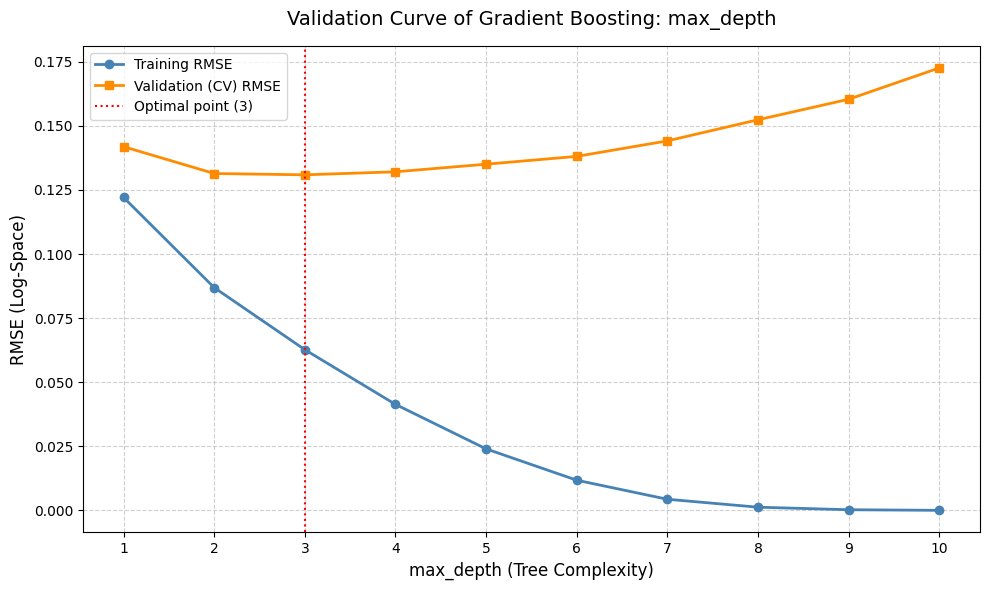

In [266]:
from sklearn.model_selection import validation_curve
# 1. 設定你要觀察的參數與範圍
# 我們來觀察 max_depth 從 1 變到 10 的過程
param_name = "max_depth"
param_range = np.arange(1, 11)

# 2. 建立基礎模型 (我們把其他參數固定在一個合理的值，避免干擾)
# 這裡先設定一個稍快的 learning_rate 讓運算快一點
gb_base = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, random_state=42)

'''
gb_base = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.0243, 
    min_samples_leaf=5,
    min_samples_split=16,
    subsample=0.7246,
    random_state=42
)
'''

print(f"正在計算 {param_name} 的驗證曲線，需進行 {len(param_range)*5} 次模型訓練，請稍候...")

# 3. 呼叫 sklearn 的 validation_curve 神器
train_scores, test_scores = validation_curve(
    estimator=gb_base,
    X=X_dev,       # 依然只能用研發集
    y=y_dev,
    param_name=param_name,
    param_range=param_range,
    cv=kf,         # 5-Fold 交叉驗證
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

# 4. 分數轉換 (把負的 MSE 轉回我們熟悉的 RMSE)
train_rmse = np.sqrt(np.abs(train_scores)).mean(axis=1)
test_rmse = np.sqrt(np.abs(test_scores)).mean(axis=1)

# ==========================================
# 5. 畫出專業級的分析圖表
# ==========================================
plt.figure(figsize=(10, 6))

# 畫訓練誤差線
plt.plot(param_range, train_rmse, label="Training RMSE", color="steelblue", marker='o', lw=2)
# 畫驗證誤差線
plt.plot(param_range, test_rmse, label="Validation (CV) RMSE", color="darkorange", marker='s', lw=2)

plt.title("Validation Curve of Gradient Boosting: max_depth", fontsize=14, pad=15)
plt.xlabel("max_depth (Tree Complexity)", fontsize=12)
plt.ylabel("RMSE (Log-Space)", fontsize=12)

# 加上隔線方便閱讀
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(param_range)
plt.legend(loc="best", fontsize=11)

plt.axvline(x=3, color='red', linestyle=':', label='Optimal point (3)')
plt.legend(loc="best")

plt.tight_layout()
plt.show()

max_depth 在 3 以前有 under fitting 的情況發生，而在 2 ~ 4 之間趨於平緩，然而當 4 之後逐漸上升造成 overfitting 

正在計算 n_estimators 的驗證曲線，這會花幾分鐘時間，請稍候...


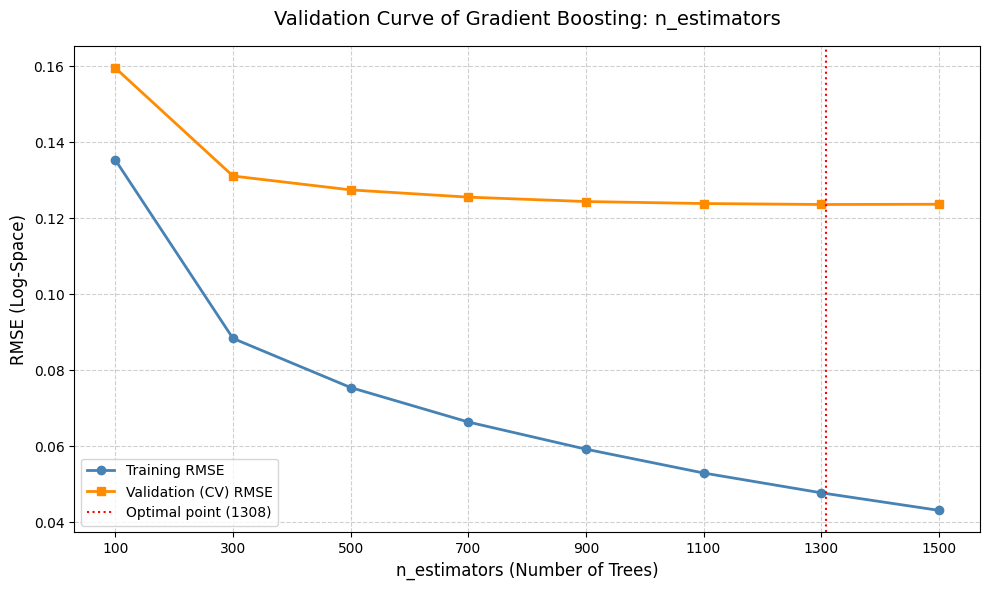

In [267]:
# 1. 設定要觀察的參數與範圍 (從 100 棵樹到 1500 棵樹，每次加 200 棵)
param_name = "n_estimators"
param_range = np.arange(100, 1600, 200)

# 2. 建立基礎模型 ★ 關鍵：把其他參數鎖定在你剛找出的「最佳組合」上
gb_base = GradientBoostingRegressor(
    learning_rate=0.0243, 
    max_depth=3,
    min_samples_leaf=5,
    min_samples_split=16,
    subsample=0.7246,
    random_state=42
)

print(f"正在計算 {param_name} 的驗證曲線，這會花幾分鐘時間，請稍候...")

# 3. 呼叫 validation_curve
train_scores, test_scores = validation_curve(
    estimator=gb_base,
    X=X_dev,
    y=y_dev,
    param_name=param_name,
    param_range=param_range,
    cv=kf,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

# 4. 分數轉換
train_rmse = np.sqrt(np.abs(train_scores)).mean(axis=1)
test_rmse = np.sqrt(np.abs(test_scores)).mean(axis=1)

# ==========================================
# 5. 畫出專業級的分析圖表
# ==========================================
plt.figure(figsize=(10, 6))

plt.plot(param_range, train_rmse, label="Training RMSE", color="steelblue", marker='o', lw=2)
plt.plot(param_range, test_rmse, label="Validation (CV) RMSE", color="darkorange", marker='s', lw=2)

plt.title("Validation Curve of Gradient Boosting: n_estimators", fontsize=14, pad=15)
plt.xlabel("n_estimators (Number of Trees)", fontsize=12)
plt.ylabel("RMSE (Log-Space)", fontsize=12)

plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(param_range)
plt.legend(loc="best", fontsize=11)

# 加上一條垂直的虛線，標示我們之前找出的最佳點 1308
plt.axvline(x=1308, color='red', linestyle=':', label='Optimal point (1308)')
plt.legend(loc="best")

plt.tight_layout()
plt.show()

從 Figure 7 (a) 我們可以看到 n_estimators = 1308 有最好的表現，然而我們會發現實際上從 700 開始便沒有明顯的進步，這是可以理解的，在我們的 CV 中 training 的總數據是 1460 的 6.4 成 (training test split and cross validation)，也就是 934.4，而我們設定的 subsample 是 0.7264 也就是說一棵樹僅能看到 678.75 的數據，而若平均分給 1308 棵樹，一棵樹能具有的資料約等於 0.52 ，若平均分給 700 棵樹，一棵樹能具有的資料約等於 0.97

雖然 n_estimators = 1308 在交叉驗證中取得了數學上的最低誤差，但由驗證曲線可知，當樹的數量超過 700 棵後，模型準確度的提升已進入邊際效益遞減 (Diminishing Marginal Returns) 的狀態。考量到模型訓練的時間成本與未來上線部署的運算資源，也可以選擇以 700 棵樹作為最佳模型，這是兼顧『預測準確度』與『系統運作效率』的最佳實務決策。

正在計算 min_samples_leaf 的驗證曲線，請稍候...


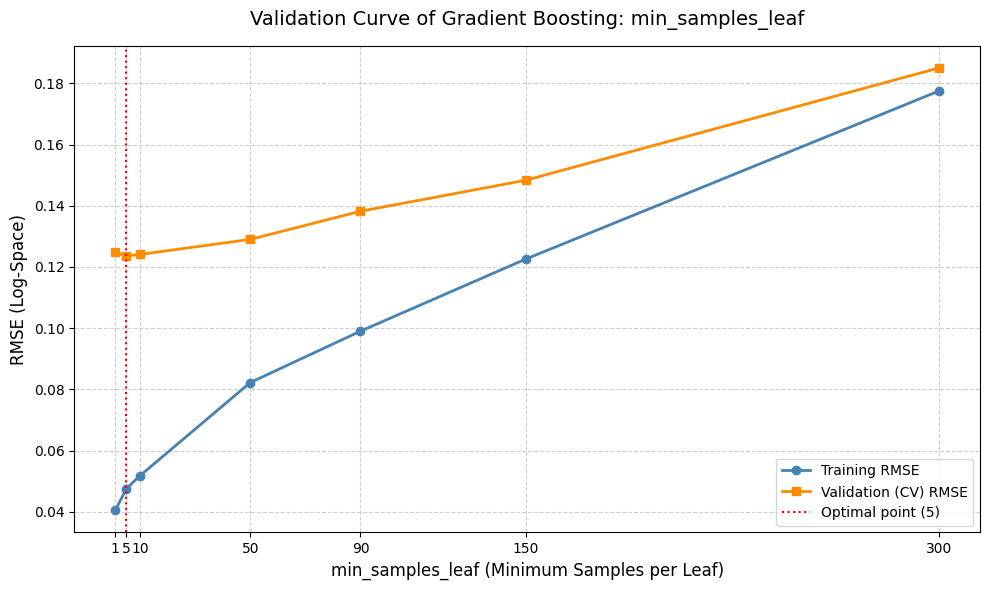

In [268]:
# 1. 設定要觀察的參數：葉節點最少樣本數 (從 1 到 20)
param_name = "min_samples_leaf"
param_range = np.array([1, 5, 10, 50, 90, 150, 300]) # 在深度 = 3 總共會有 2^3 = 8 棵樹 ， 總共 1460*0.8 = 1168 筆資料 
                                                     # 平均一棵樹可分到 148 筆資料
# 2. 建立基礎模型 
gb_base = GradientBoostingRegressor(
    n_estimators=1308,       
    learning_rate=0.0243, 
    max_depth=3,
    min_samples_split=16,
    subsample=0.7246,
    random_state=42
)

print(f"正在計算 {param_name} 的驗證曲線，請稍候...")

# 3. 呼叫 validation_curve
train_scores, test_scores = validation_curve(
    estimator=gb_base,
    X=X_dev,
    y=y_dev,
    param_name=param_name,
    param_range=param_range,
    cv=kf,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

# 4. 分數轉換
train_rmse = np.sqrt(np.abs(train_scores)).mean(axis=1)
test_rmse = np.sqrt(np.abs(test_scores)).mean(axis=1)

# ==========================================
# 5. 畫出專業級的分析圖表
# ==========================================
plt.figure(figsize=(10, 6))

plt.plot(param_range, train_rmse, label="Training RMSE", color="steelblue", marker='o', lw=2)
plt.plot(param_range, test_rmse, label="Validation (CV) RMSE", color="darkorange", marker='s', lw=2)

plt.title("Validation Curve of Gradient Boosting: min_samples_leaf", fontsize=14, pad=15)
plt.xlabel("min_samples_leaf (Minimum Samples per Leaf)", fontsize=12)
plt.ylabel("RMSE (Log-Space)", fontsize=12)

plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(param_range)
plt.legend(loc="best", fontsize=11)

# 加上一條垂直的虛線，標示我們之前找出的最佳點 5
plt.axvline(x=5, color='red', linestyle=':', label='Optimal point (5)')
plt.legend(loc="best")

plt.tight_layout()
plt.show()

「邊界測試：146 筆資料的物理極限」在 max_depth = 3 的架構下，決策樹最多展開 8 個葉節點。將 1168 筆訓練樣本平均分配，每個葉節點的理論容量極限為 146 筆。為了驗證此數學限制，本研究刻意將 min_samples_leaf 設定在臨界點 150 與極端點 300 進行測試。如驗證曲線所示：觸碰極限 (Leaf = 150)： 由於限制條件 (150) 微幅超過了自然分配極限 (146)，模型被迫提早停止生長 (Early Stopping)，訓練與驗證誤差在此處產生了明顯的向上轉折。結構瓦解 (Leaf = 300)： 當限制提高至 300 時，模型最多僅能生成 3 個葉節點 ($1168 \div 300 \approx 3.89$)。原本深度的優勢被徹底抹殺，導致誤差雙雙飆升，形成嚴重欠擬合 (Severe Underfitting)。結論： 此次破壞性實驗完美吻合了我們的數學推導，再次確立了採用寬鬆限制 (leaf = 5) 以釋放模型潛力的正確性。

正在計算 learning_rate 的驗證曲線，這會花幾分鐘，請稍候...


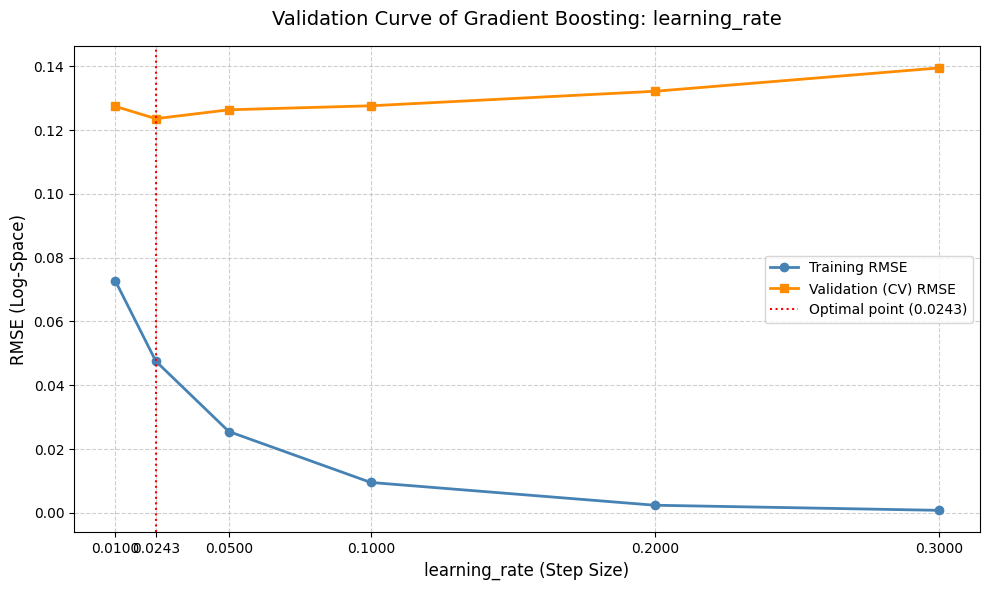

In [269]:
# 1. 設定要觀察的參數：學習率 (從極小 0.01 到 較大 0.3)
param_name = "learning_rate"
# 我們測試這幾個關鍵點：0.01, 0.0243(你的最佳點), 0.05, 0.1, 0.2, 0.3
param_range = np.array([0.01, 0.0243, 0.05, 0.1, 0.2, 0.3])

# 2. 建立基礎模型 ★ 關鍵：鎖定 1308 棵樹、深度 3、葉子 5
gb_base = GradientBoostingRegressor(
    n_estimators=1308,      
    max_depth=3,
    min_samples_leaf=5,
    min_samples_split=16,
    subsample=0.7246,
    random_state=42
)

print(f"正在計算 {param_name} 的驗證曲線，這會花幾分鐘，請稍候...")

# 3. 呼叫 validation_curve
train_scores, test_scores = validation_curve(
    estimator=gb_base,
    X=X_dev,
    y=y_dev,
    param_name=param_name,
    param_range=param_range,
    cv=kf,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

# 4. 分數轉換
train_rmse = np.sqrt(np.abs(train_scores)).mean(axis=1)
test_rmse = np.sqrt(np.abs(test_scores)).mean(axis=1)

# ==========================================
# 5. 畫出專業級的分析圖表
# ==========================================
plt.figure(figsize=(10, 6))

plt.plot(param_range, train_rmse, label="Training RMSE", color="steelblue", marker='o', lw=2)
plt.plot(param_range, test_rmse, label="Validation (CV) RMSE", color="darkorange", marker='s', lw=2)

plt.title("Validation Curve of Gradient Boosting: learning_rate", fontsize=14, pad=15)
plt.xlabel("learning_rate (Step Size)", fontsize=12)
plt.ylabel("RMSE (Log-Space)", fontsize=12)

plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(param_range)

# 加上一條垂直的虛線，標示我們之前找出的最佳點 0.0243
plt.axvline(x=0.0243, color='red', linestyle=':', label='Optimal point (0.0243)')
plt.legend(loc="best")

plt.tight_layout()
plt.show()

從 learning rate 我們可以看出在 0.0243 具有最小的 validation error，而小於此數據有較大的 error 表示 underfitting 而隨著 learning rate 增加 validation error 也逐漸增加，顯示有 overfitting 的情況發生

正在計算 subsample 的驗證曲線，請稍候...


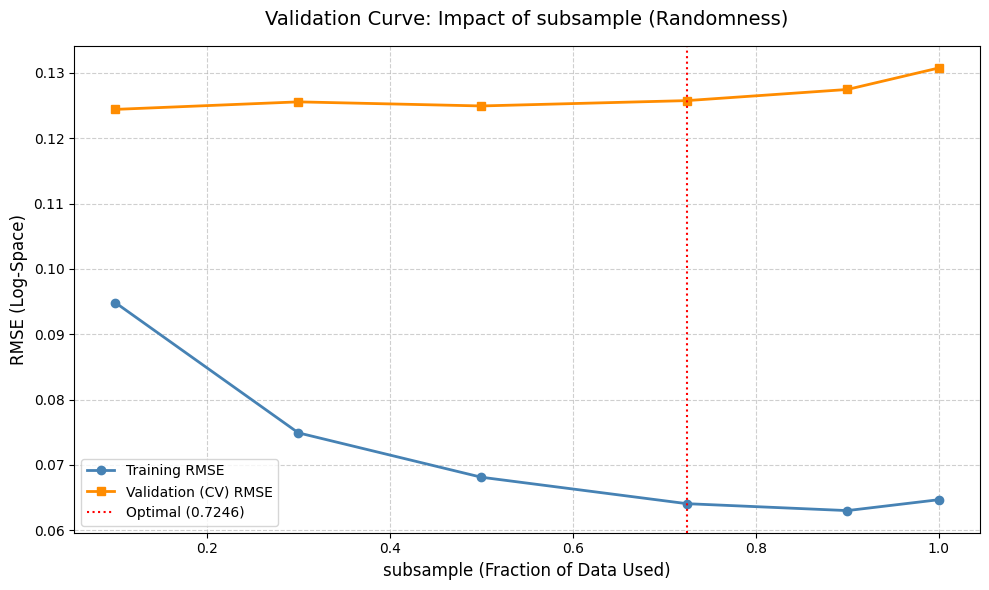

In [270]:
# 1. 建立基礎模型 (700 棵樹, 深度 3, 學習率 0.0243, 葉子 5)
gb_base_sub = GradientBoostingRegressor(
    n_estimators=700, 
    learning_rate=0.0243, 
    max_depth=3, 
    min_samples_leaf=5,
    random_state=42
)

# 2. 設定測試範圍 (從看 10% 資料，到看 100% 資料)
param_range_subsample = np.array([0.1, 0.3, 0.5, 0.7246, 0.9, 1.0])

print("正在計算 subsample 的驗證曲線，請稍候...")

# 3. 計算驗證曲線
train_scores_sub, test_scores_sub = validation_curve(
    estimator=gb_base_sub, 
    X=X_dev, y=y_dev, 
    param_name="subsample",
    param_range=param_range_subsample, 
    cv=kf, scoring="neg_mean_squared_error", n_jobs=-1
)

# 4. 轉換分數
train_rmse_sub = np.sqrt(np.abs(train_scores_sub)).mean(axis=1)
test_rmse_sub = np.sqrt(np.abs(test_scores_sub)).mean(axis=1)

# 5. 繪製圖表
plt.figure(figsize=(10, 6))
plt.plot(param_range_subsample, train_rmse_sub, label="Training RMSE", color="steelblue", marker='o', lw=2)
plt.plot(param_range_subsample, test_rmse_sub, label="Validation (CV) RMSE", color="darkorange", marker='s', lw=2)

plt.title("Validation Curve: Impact of subsample (Randomness)", fontsize=14, pad=15)
plt.xlabel("subsample (Fraction of Data Used)", fontsize=12)
plt.ylabel("RMSE (Log-Space)", fontsize=12)

plt.grid(True, linestyle='--', alpha=0.6)
plt.axvline(x=0.7246, color='red', linestyle=':', label='Optimal (0.7246)')
plt.legend(loc="best")
plt.tight_layout()
plt.show()

本圖表展示了 subsample（每次建樹時隨機抽樣的資料比例）對模型誤差的影響。觀察驗證曲線（深藍線），我們可以將模型的表現劃分為三個階段，並從中印證隨機梯度提升樹 (Stochastic Gradient Boosting) 的數學特性：

1. 資訊匱乏區 (Subsample = 0.1 ~ 0.3)：嚴重的欠擬合 (Underfitting)
當抽樣比例過低時（例如僅取 10%），每棵決策樹能獲得的資訊極度破碎。觀察藍線可知，此時的訓練誤差（Training RMSE）處於全局最高點，這表明模型因受限於資料量而呈現明顯的高偏差 (High Bias) 與欠擬合狀態。儘管這種極端的隨機性強制壓抑了驗證誤差（橘線呈現平緩），但這是一種受限於模型容量不足的「假性收斂」。模型實際上並未充分學習到數據中深層的非線性市場特徵，因此在實務上不可採用。

2. 效能甜蜜點 (Subsample = 0.5 ~ 0.9) 與 0.7246 的決策邏輯
當抽樣比例來到 0.5 至 0.9 的區間時，驗證誤差降至最低並形成一個平緩的「波谷」。
從單一維度的視覺上來看，0.5 的驗證誤差看似微幅低於 0.7246（差距約在 0.001 的統計誤差範圍內）。然而，本專案最終仍定案於 0.7246，其背後有兩大科學考量：

多維度全局最佳解 (Global Optimum)： 0.7246 是透過 RandomizedSearchCV 在包含學習率、樹深度、葉節點限制等多維度參數空間中，綜合評估找出的「全局最佳組合」。單一參數切面下的局部低點 (Local Minimum)，並不代表在整體架構下能發揮最佳協同效應。

資訊保留與隨機性的平衡： 採用 0.72 的比例能讓模型在「保留高達七成真實房價資訊」的同時，依然維持足夠的隨機性，這比僅使用 50% 資料的風險更低、預測更穩健。

3. 過度擬合的翹尾現象 (Subsample = 1.0)：喪失隨機性防護
圖表最右側 (1.0) 呈現了非常關鍵的現象：當我們放棄隨機抽樣，讓每棵樹都看 100% 相同的訓練資料時，訓練誤差（橘線）持續下降，但驗證誤差（藍線）卻出現了明顯的向上反折（翹尾）。
這證明了當群體模型中的每一棵樹都看著一模一樣的資料生長時，它們的預測行為會高度相關 (Highly Correlated)，進而集體「死背」訓練集中的極端值與雜訊。適度的隨機抽樣（如定案的 0.72）能打破這種相關性，是防止群體模型過度擬合不可或缺的防護機制。

正在計算 min_samples_split 的驗證曲線，請稍候...


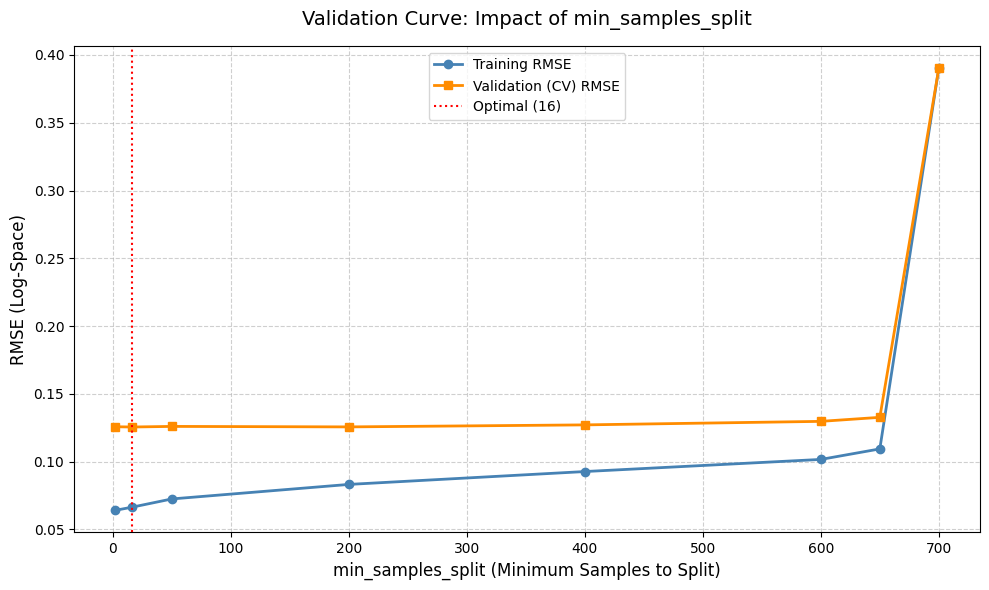

In [271]:
# 1. 建立基礎模型 ★ 注意：這裡已經把 subsample=0.7246 鎖定加入了
gb_base_split = GradientBoostingRegressor(
    n_estimators=700, 
    learning_rate=0.0243, 
    max_depth=3, 
    min_samples_leaf=5,
    subsample=0.7246, 
    random_state=42
)

# 2. 設定測試範圍 (從 2 到 200)
param_range_split = np.array([2, 16, 50, 200, 400, 600, 650, 700])

print("正在計算 min_samples_split 的驗證曲線，請稍候...")

# 3. 計算驗證曲線
train_scores_split, test_scores_split = validation_curve(
    estimator=gb_base_split, 
    X=X_dev, y=y_dev, 
    param_name="min_samples_split",
    param_range=param_range_split, 
    cv=kf, scoring="neg_mean_squared_error", n_jobs=-1
)

# 4. 轉換分數
train_rmse_split = np.sqrt(np.abs(train_scores_split)).mean(axis=1)
test_rmse_split = np.sqrt(np.abs(test_scores_split)).mean(axis=1)

# 5. 繪製圖表
plt.figure(figsize=(10, 6))
plt.plot(param_range_split, train_rmse_split, label="Training RMSE", color="steelblue", marker='o', lw=2)
plt.plot(param_range_split, test_rmse_split, label="Validation (CV) RMSE", color="darkorange", marker='s', lw=2)

plt.title("Validation Curve: Impact of min_samples_split", fontsize=14, pad=15)
plt.xlabel("min_samples_split (Minimum Samples to Split)", fontsize=12)
plt.ylabel("RMSE (Log-Space)", fontsize=12)

plt.grid(True, linestyle='--', alpha=0.6)
plt.axvline(x=16, color='red', linestyle=':', label='Optimal (16)')
plt.legend(loc="best")
plt.tight_layout()
plt.show()

在回歸問題（房價預測）中，決策樹追求的是**「最大化降低均方誤差 (MSE)」**（這對應於分類問題中的 Entropy / Gini Impurity）。

真實世界中的資料分布極度不均。模型在切第一刀的時候，絕對不會乖乖地把 846 筆資料切成 423 跟 423。

非對稱分裂： 如果有一個特徵（例如：「是否為超級豪宅區」）能極大地降低 Impurity，模型會毫不猶豫地切出一邊 700 棟（普通住宅）、一邊 146 棟（豪宅）的極端分佈。

「偏癱」的決策樹： 當你設定 min_samples_split = 600 時，右邊那 146 棟的節點確實被「勒死」了（停止生長）。但是！左邊那高達 700 棟的主力節點，依然符合大於 600 的門檻，所以它可以繼續往下切第 2 層、甚至第 3 層。

「從分裂門檻 (min_samples_split) 洞見決策樹的非對稱生長機制」

在極限壓力測試中，我們觀察到 min_samples_split 即使提升至 600，驗證誤差仍保持高度平穩，直至 700 才發生斷崖式崩潰 (RMSE 飆升至 0.39)。

傳統直覺認為樣本會均勻分裂，然而此現象證實了演算法底層是基於最大化降低不純度 (Impurity Reduction) 進行非對稱分裂 (Asymmetric Splitting)。即使設定高分裂門檻，迫使包含少數極端值的「瘦節點」提早停止生長，但包含多數樣本的「主幹節點」仍能滿足門檻並持續向下分裂至 Depth 3。這使得模型在極高約束下，依然能保留對主體資料的強大預測力。

此實驗不僅驗證了 Gradient Boosting 的強大Robustness，更透過 700 處的崩潰點，反向推導出本模型根節點/主節點的有效樣本池規模約落於 650 至 700 之間。

C:\Users\j1456\AppData\Local\Temp\ipykernel_19140\1747475382.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


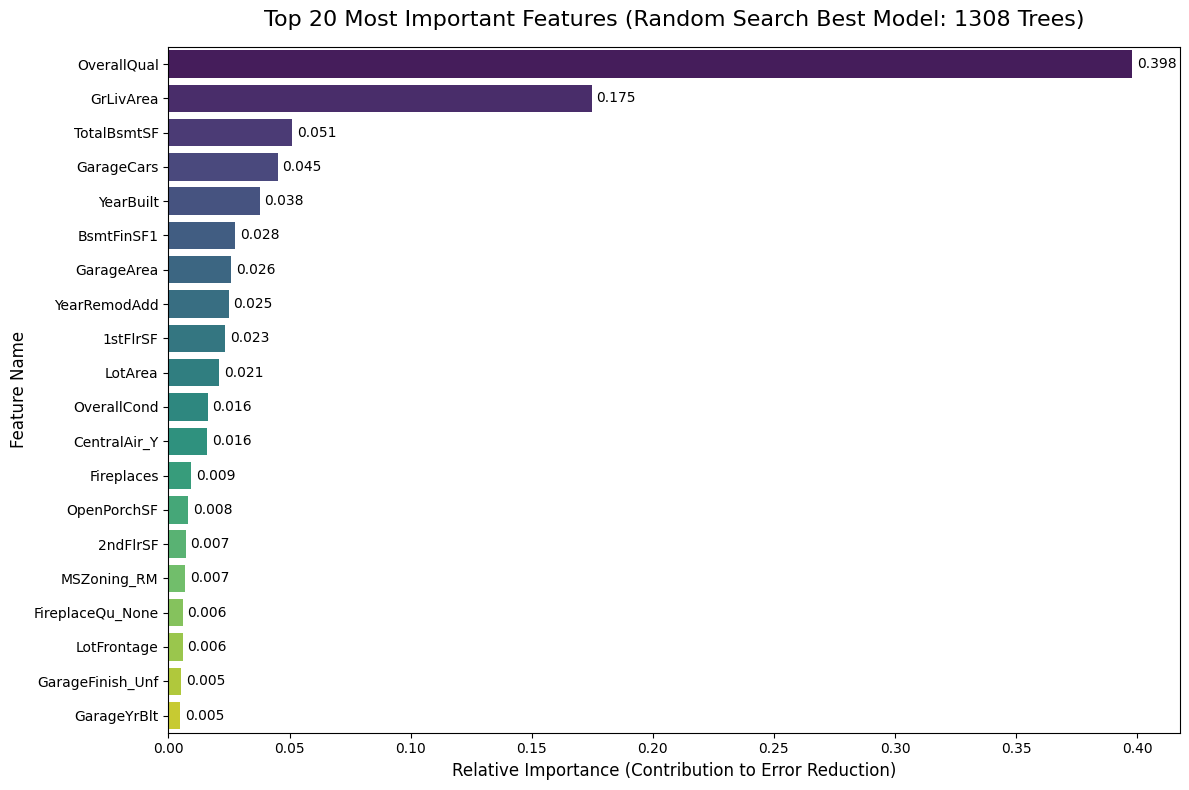


 1308 人菁英團隊揭曉：Top 5 絕對關鍵特徵 ✨
  1. OverallQual (權重: 0.398)
  2. GrLivArea (權重: 0.175)
  3. TotalBsmtSF (權重: 0.051)
  4. GarageCars (權重: 0.045)
  5. YearBuilt (權重: 0.038)


In [272]:
# 1. 提取特徵重要性 (直接從你的 best_gb_random_model 拿)
importances = best_gb_random_model.feature_importances_
feature_names = X_dev.columns

# 2. 將結果打包成 DataFrame 並排序
feature_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})
top_20_features = feature_imp_df.sort_values(by='Importance', ascending=False).head(20)

# 3. 繪製精美的橫向長條圖
plt.figure(figsize=(12, 8))
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=top_20_features,
    palette='viridis' # 使用漸層色，越重要的顏色越深
)

plt.title('Top 20 Most Important Features (Random Search Best Model: 1308 Trees)', fontsize=16, pad=15)
plt.xlabel('Relative Importance (Contribution to Error Reduction)', fontsize=12)
plt.ylabel('Feature Name', fontsize=12)

# 加上數值標籤讓報告更專業
for index, value in enumerate(top_20_features['Importance']):
    plt.text(value + 0.002, index, f'{value:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

# 4. 印出文字版 Top 5
print("\n" + "="*50)
print(" 1308 人菁英團隊揭曉：Top 5 絕對關鍵特徵 ✨")
for i, (feat, imp) in enumerate(zip(top_20_features['Feature'].head(5), top_20_features['Importance'].head(5))):
    print(f"  {i+1}. {feat} (權重: {imp:.3f})")
print("="*50)

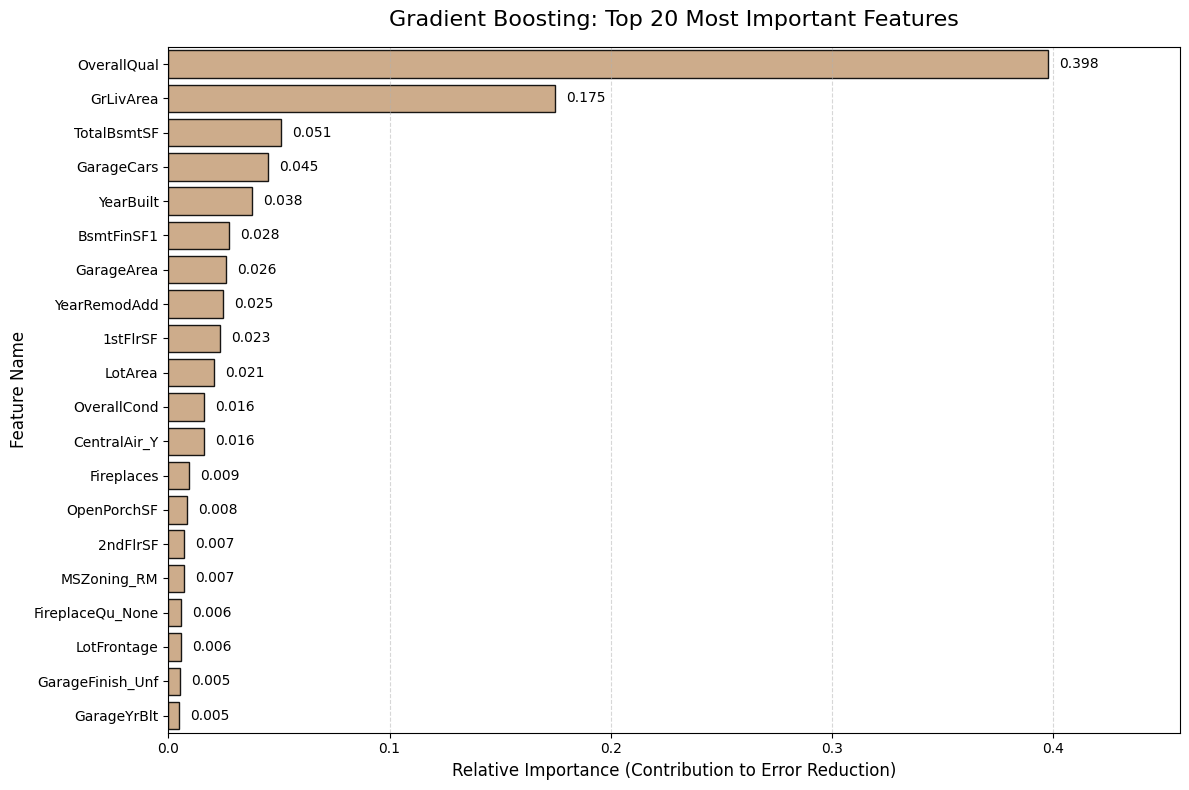


 1308 人菁英團隊揭曉：Top 5 絕對關鍵特徵 ✨
  1. OverallQual (權重: 0.398)
  2. GrLivArea (權重: 0.175)
  3. TotalBsmtSF (權重: 0.051)
  4. GarageCars (權重: 0.045)
  5. YearBuilt (權重: 0.038)


In [273]:
# 1. 提取特徵重要性 (直接從你的 best_gb_random_model 拿)
importances = best_gb_random_model.feature_importances_
feature_names = X_dev.columns

# 2. 將結果打包成 DataFrame 並排序
feature_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})
top_20_features = feature_imp_df.sort_values(by='Importance', ascending=False).head(20)

# 3. 繪製精美的橫向長條圖
plt.figure(figsize=(12, 8))

# 🌟 關鍵修改：取消漸層，換上 GBR 專屬的赭金色，並加上黑色俐落邊框
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=top_20_features,
    color='#D4A373',      # 統一 GBR 視覺主題色
    edgecolor='black',    # 加上邊框提升學術質感
    alpha=0.9             # 稍微透氣
)

plt.title('Gradient Boosting: Top 20 Most Important Features', fontsize=16, pad=15)
plt.xlabel('Relative Importance (Contribution to Error Reduction)', fontsize=12)
plt.ylabel('Feature Name', fontsize=12)

# 🌟 新增：加入垂直網格線 (與線性模型的圖表背景對齊)
plt.grid(axis='x', linestyle='--', alpha=0.5)

# 加上數值標籤讓報告更專業 (稍微加大 x 軸偏移量至 0.005，避免與黑色邊框重疊)
for index, value in enumerate(top_20_features['Importance']):
    plt.text(value + 0.005, index, f'{value:.3f}', va='center', fontsize=10)

plt.xlim(0, max(top_20_features['Importance']) * 1.15)
plt.tight_layout()

# 儲存圖片 (準備放進 LaTeX 報告)
plt.savefig('GBR_influential_features_unified.png', dpi=300, bbox_inches='tight')

plt.show()

# 4. 印出文字版 Top 5
print("\n" + "="*50)
print(" 1308 人菁英團隊揭曉：Top 5 絕對關鍵特徵 ✨")
for i, (feat, imp) in enumerate(zip(top_20_features['Feature'].head(5), top_20_features['Importance'].head(5))):
    print(f"  {i+1}. {feat} (權重: {imp:.3f})")
print("="*50)

「地段的迷思？線性與非線性模型的特徵決策差異」

觀察現象：
特徵 Neighborhood_StoneBr 在 Lasso/Ridge 中名列前三，但在 Gradient Boosting (GB) 的 Top 20 榜單中卻完全消失。

原理解析：

特徵碎裂化弱勢： Neighborhood 經 One-Hot Encoding 後產生極度稀疏的二元特徵（多數值為 0）。GB 傾向於優先選擇連續型變數（如 GrLivArea）進行分裂，以獲取最大的全局不純度降低 (Impurity Reduction)。

多重共線性與遮蔽效應 (Masking Effect)： 高價社區的本質通常伴隨著高建材品質與大坪數。GB 演算法在頂層節點優先選用了 OverallQual 與 GrLivArea 進行分裂，這兩個強勢特徵已經完美捕捉了高價房屋的變異性。這導致 Neighborhood 的資訊被「遮蔽」，在決策樹眼中失去殘餘的預測價值（重要性歸零）。相對地，線性模型則會將這些附加價值獨立賦予給地段係數。

實務結論： > 線性模型告訴我們「高價的標籤在哪裡（地段）」，而 GB 模型則揭露了「造就高價的本質是什麼（品質與面積）」。